# 1. Setup

## 1.1 Imports

In [1]:
import pandas as pd
import numpy as np

from pathlib import Path

import matplotlib.pyplot as plt

from numpy.linalg import lstsq
from scipy.stats import kruskal
import scikit_posthocs as sp
import statsmodels.formula.api as smf
import seaborn as sns

## 1.2 Paths

In [2]:
input_path = Path("data/input/08_input")
output_path = Path("data/output/08_output")

## 1.3 Store TXT files as CSV

In [3]:
for file_path in input_path.iterdir():
    # Skip directories, hidden/system files (e.g. .DS_Store), and any
    # non-data files. Adjust the suffix set to match your raw extensions.
    if not file_path.is_file():
        continue
    if file_path.name.startswith("."):
        continue
    if file_path.suffix.lower() not in {".txt", ".csv"}:
        continue

    file = pd.read_csv(file_path, sep="|")
    file.to_csv(file_path.with_suffix(".csv"), sep="|", index=False)

# 2. Clinical outcomes (predefined from V06)

In [4]:
# Read file
all_clinical_08 = pd.read_csv(input_path / "AllClinical08.csv", sep="|")

## 2.1 Aggregate x-ray dataset fo KL grade

In [5]:
"""
V08XRKL defines Kellgren and Lawrence grade from 0-4
0 = none (definite absence of x-ray changes of osteoarthritis)
1 = doubtful (doubtful joint space narrowing and possible osteophytic lipping)
2 = minimal (definite osteophytes and possible joint space narrowing)
3 = moderate (moderate multiple osteophytes, definite narrowing of joint space, some sclerosis and possible deformity of bone ends)
4 = severe (large osteophytes, marked narrowing of joint space, severe sclerosis and definite deformity of bone ends)
"""

xr_df = pd.read_csv(input_path / "KXR_SQ_BU08.csv", sep="|")

# select Kellgren and Lawrence Score and take max grade per ID and side
xr_df_grade = xr_df[["ID", "SIDE", "V08XRKL"]]
xr_df_grade = xr_df_grade.groupby(["ID", "SIDE"])["V08XRKL"].max().reset_index()

# clean label format from SIDE and V08XRKL (e.g. "1: Right" --> "Right", "2: 2" -> "2")
xr_df_grade["SIDE"] = xr_df_grade["SIDE"].str.extract(r":\s*(\w+)")
xr_df_grade["V08XRKL"] = xr_df_grade["V08XRKL"].str.extract(r":\s*(\d+)").squeeze().astype(float).astype("Int64")

# Pivot from long to wide format -> one row per ID, separate columns for Left and Right
xr_df_wide = xr_df_grade.pivot(index="ID", columns="SIDE", values="V08XRKL")
xr_df_wide.columns = [f"V08XRKL_{col}" for col in xr_df_wide.columns]
xr_df_wide = xr_df_wide.reset_index()

print(xr_df_wide)

           ID  V08XRKL_Left  V08XRKL_Right
0     9000798          <NA>              1
1     9001695             0              3
2     9001897             1              3
3     9002316             2              1
4     9002817             2              3
...       ...           ...            ...
2310  9997869             1              3
2311  9998089             1              2
2312  9999295             0              2
2313  9999510             3              2
2314  9999878             1              2

[2315 rows x 3 columns]


## 2.2 Merge x-ray with clinical dataset

In [6]:
all_clinical_08_merged = xr_df_wide.merge(all_clinical_08, on="ID", how="inner")

## 2.3 Predefined outcome variables (anchor_correlated_outcome_variables, V08 names)

In [16]:
final_outcome_variables = [
    # pain_right — |rho| >= 0.20 threshold applied
    "V08KOOSKPR",  # KOOS Pain right knee — preferred over WOMAC (contains WOMAC, 0-100 scale)
    "V08ICPTSKR",  # ICOAP Right knee: Intermittent and Constant Pain Total Score, 0-100

    "V08KGLRS",    # Global knee rating — patient impression, distinct construct

    # pain_left — |rho| >= 0.20 threshold applied
    "V08KOOSKPL",  # KOOS Pain left knee
    "V08ICPTSKL",  # ICOAP Left knee: Intermittent and Constant Pain Total Score

    # function — |rho| >= 0.10 threshold applied
    "V0820MPACE",  # 20m walk pace (m/s) — represents full 20m walk cluster
    "V08CSTIME1",  # Repeated chair stand: time
    "V08STEPST1",  # 20-meter walk: trial 1 number of steps

    # self-reported function right
    "V08WOMADLR",  # Right knee: WOMAC Disability Score (task-level self-reported function)
    "V08KOOSYMR",  # Right knee: KOOS Symptoms Score (distinct from pain and function)

    # self-reported function left
    "V08WOMADLL",  # Left knee: WOMAC Disability Score (task-level self-reported function)
    "V08KOOSYML",  # Left knee: KOOS Symptoms Score (distinct from pain and function)

    # self-reported function bilateral
    "V08KOOSFSR",  # KOOS Function, Sport and Recreation subscale (person-level)

    # depression
    "V08CESD",     # CES-D total score

     # participation — |rho| >= 0.10 threshold applied
    "V08LLDILST",  # LLDI Limitation dimension total (perceived participation restriction)
    "V08LLDIFST",  # LLDI Frequency dimension total (frequency of participation)
]

In [17]:
all_clinical_08_merged.to_csv(output_path / "all_clinical_08_merged.csv", sep="|", index=False)

# 3. Build cohort dataframes

## 3.1 Create Subject Summary Metrics dataframe

In [18]:
# drop non-participants from the Accelerometry data for valid ID's
Accelerometry08 = pd.read_csv(input_path / "Accelerometry08.csv", sep="|")

accelerometry_valid_participants_08 = Accelerometry08[Accelerometry08["V08APASTAT"] != "Not participating"]

In [19]:
# create summary_metrics_08 dataframe with relevant columns from accelerometry_valid_participants_08, all_clinical_08, and x-ray dataset (KL grade) and enrollees dataset

summary_metrics_08 = pd.DataFrame()

"""
Decision to use Trioano cut points for activity intensity classification, as these were validated in a population with rheumatic diseases and are commonly used in OAI accelerometer research. Freedson was validated on young healthy adults and underestimates MVPA in older populations, while Swartz overestimates it. The cut points are based on counts per minute (cpm) thresholds that correspond to different activity intensities:
light: 100-2019 cpm
moderate: 2020-5998 cpm
vigorous: >= 5999 cpm
"""

activity_cols = [
    "ID",
    "V08AACNT", # average daily counts
    "V08AALTMNT", # average daily light activity counts Trioano
    "V08AAMDMNT", # average daily moderate activity counts Trioano
    "V08AAMVMNT", # average daily moderate/vigorous activity counts Trioano
    "V08AAVMNT", # average daily vigorous activity counts Trioano
    "V08ANVDAYS", # number of valid days (exposed downstream as valid_days_oai)

    "V08AACSM03", # >= 30 minutes of moderate-intensity activity per day 0-1
    "V08ADHHS8", # >= 150 minutes of moderate activity and >=75 minutes of vigorous minutes per week 0 or 1
    "V08ADHHSD8", # >= 150 minutes of moderate-intensity activity per week 0 or 1
]

summary_metrics_08 = accelerometry_valid_participants_08[activity_cols].rename(
    columns={"V08ANVDAYS": "valid_days_oai"}
)

In [20]:
print(f"Accelerometer participants: {Accelerometry08["ID"].nunique()}")
print(f"Accelerometer participants that participated: {accelerometry_valid_participants_08['ID'].nunique()}")
print(f"After merge: {summary_metrics_08['ID'].nunique()}")

Accelerometer participants: 1797
Accelerometer participants that participated: 1521
After merge: 1521


## 3.2 Restrict V08 cohort to V06 analytic sample

In [21]:
# Load the final V06 analytic cohort (post KL-grade, post-surgery filtering)
# to define eligibility for longitudinal validation.
summary_metrics_06 = pd.read_csv(Path("data/output/06_output") / "summary_metrics_06.csv",sep="|",)
v06_cohort_ids = set(summary_metrics_06["ID"])

In [22]:
participants_before = summary_metrics_08["ID"].nunique()
summary_metrics_08 = summary_metrics_08[
    summary_metrics_08["ID"].isin(v06_cohort_ids)
].copy()
participants_after = summary_metrics_08["ID"].nunique()
print(f"V08 before V06 restriction: {participants_before:,}")
print(f"V08 after V06 restriction:  {participants_after:,}")
print(f"Dropped (not in V06 cohort): {participants_before - participants_after:,}")

V08 before V06 restriction: 1,521
V08 after V06 restriction:  1,080
Dropped (not in V06 cohort): 441


In [23]:
# merge outcome variables from all_clinical_08_merged
all_clinical_cols = [
    # basic parameter"ID",
    "ID", "V08AGE", "V08WEIGHT", "V08BMI", "V08COMORB", "V08CEMPLOY",
]
summary_metrics_08 = summary_metrics_08.merge(all_clinical_08_merged[all_clinical_cols], on="ID", how="left")
summary_metrics_08 = summary_metrics_08.merge(
    right=all_clinical_08_merged[["ID"] + final_outcome_variables],
    on="ID",
    how="left",
)

In [24]:
print(summary_metrics_08.columns)

Index(['ID', 'V08AACNT', 'V08AALTMNT', 'V08AAMDMNT', 'V08AAMVMNT', 'V08AAVMNT',
       'valid_days_oai', 'V08AACSM03', 'V08ADHHS8', 'V08ADHHSD8', 'V08AGE',
       'V08WEIGHT', 'V08BMI', 'V08COMORB', 'V08CEMPLOY', 'V08KOOSKPR',
       'V08ICPTSKR', 'V08KGLRS', 'V08KOOSKPL', 'V08ICPTSKL', 'V0820MPACE',
       'V08CSTIME1', 'V08STEPST1', 'V08WOMADLR', 'V08KOOSYMR', 'V08WOMADLL',
       'V08KOOSYML', 'V08KOOSFSR', 'V08CESD', 'V08LLDILST', 'V08LLDIFST'],
      dtype='str')


### Aggregate Enrollees for SEX column

In [25]:
enrollees_df = pd.read_csv(input_path / "Enrollees.csv", sep="|")

#clean label format from P02SEX (e.g. "1: Male" --> "Male")
enrollees_df["P02SEX"] = enrollees_df["P02SEX"].str.extract(r":\s*(\w+)")


### Merge summary_metrics_08 with x-ray (KL grade) and enrollees (sex)

In [26]:
summary_metrics_08 = (summary_metrics_08
                      .merge(xr_df_wide, on="ID", how="inner")
                      .merge(enrollees_df[["ID", "P02SEX"]], on="ID", how="inner")
                      )

# Verify — any drop beyond accelerometer filtering is a data quality signal
accelerometer_participant_count = accelerometry_valid_participants_08["ID"].nunique()
final_participant_count = summary_metrics_08["ID"].nunique()

# include KL grade per patient for later use in stratification and subgroup analyses; use worse knee (max of left and right) as KL grade per patient
kl_grade_per_patient = (
    xr_df_wide[["ID", "V08XRKL_Left", "V08XRKL_Right"]]
    .copy()
)
kl_grade_per_patient["kl_grade_index_knee"] = kl_grade_per_patient[
    ["V08XRKL_Left", "V08XRKL_Right"]
].max(axis=1)

# Merge KL grade into summary data
summary_metrics_08 = summary_metrics_08.merge(
    kl_grade_per_patient[["ID", "kl_grade_index_knee"]],
    on="ID",
    how="left",
)

print(f"Final participants after all merges: {final_participant_count}")

Final participants after all merges: 831


In [27]:
restricted_ids = set(summary_metrics_06["ID"]) & set(accelerometry_valid_participants_08["ID"])
xr_ids  = set(xr_df_wide["ID"])
enr_ids = set(enrollees_df["ID"])

print(f"Cohort missing V08 x-ray:    {len(restricted_ids - xr_ids):,}")
print(f"Cohort missing enrollee row: {len(restricted_ids - enr_ids):,}")

Cohort missing V08 x-ray:    249
Cohort missing enrollee row: 0


In [28]:
summary_metrics_08.to_csv(output_path / "summary_metrics_08.csv", sep="|", index=False)
print(summary_metrics_08.shape)

(831, 35)


## 3.3 Drop participants with prior knee surgery (v07, v08)

In [29]:
clinical_frames_by_visit = {
"v07": pd.read_csv(input_path / "AllClinical07.csv", sep="|"),
"v08": pd.read_csv(input_path / "AllClinical08.csv", sep="|"),
}

In [30]:
ID_COLUMN: str = "ID"
YES_CODE: int = 1  # confirmed encoding: 1 = Yes (surgery), 0 = No

# Each visit's right/left "surgery or arthroscopy" variables. Baseline (P01)
# asks "ever"; each follow-up asks "since last visit ~12 months". The union
# across visits gives cumulative surgery history up to V08.
SURGERY_ITEMS_BY_VISIT: dict[str, tuple[str, str]] = {
    # visit_code: (right_knee_variable, left_knee_variable)
    "v07": ("V07KSRGR12", "V07KSRGL12"),
    "v08": ("V08KSRGR12", "V08KSRGL12"),
}

In [31]:
def parse_surgery_code(raw_series: pd.Series) -> pd.Series:
    """Parse an OAI surgery item into a numeric code (0 = No, 1 = Yes).

    Handles both labelled values such as ``"1: Yes"`` and bare values such as
    ``1`` or ``"0"``. Any value whose leading token is not a digit (for example
    ``".: Missing Form/Incomplete Workbook"``) becomes missing.

    :param raw_series: Surgery item as read from the clinical file.
    :returns: Numeric series with missing values for non-coded entries.
    """
    leading_token = raw_series.astype(str).str.strip().str.split(":").str[0]
    return pd.to_numeric(leading_token, errors="coerce")

def merge_surgery_columns(
    clinical_frames_by_visit: dict[str, pd.DataFrame],
    *,
    surgery_items_by_visit: dict[str, tuple[str, str]] = SURGERY_ITEMS_BY_VISIT,
    id_column: str = ID_COLUMN,
) -> pd.DataFrame:
    """Merge the right/left surgery columns from every visit onto one frame.

    Only the identifier and the two surgery variables are taken from each
    visit, then merged on the identifier with an outer join so that no
    participant is dropped for being absent at a given visit. Surgery codes are
    coerced to numeric, turning blanks and stray codes into missing values.

    :param clinical_frames_by_visit: Mapping from visit label to its loaded
        data frame. Must contain every visit named in ``surgery_items_by_visit``.
    :param surgery_items_by_visit: Mapping from visit label to the right- and
        left-knee surgery variable names for that visit.
    :param id_column: Name of the participant identifier column.
    :returns: One row per participant, indexed by identifier, containing the
        surgery columns from all visits as numeric values.
    """
    merged_surgery_data: pd.DataFrame | None = None

    for visit_label, surgery_columns in surgery_items_by_visit.items():
        if visit_label not in clinical_frames_by_visit:
            raise KeyError(f"No data frame supplied for visit '{visit_label}'.")

        clinical_frame = clinical_frames_by_visit[visit_label]
        right_column, left_column = surgery_columns

        missing_columns = {id_column, right_column, left_column} - set(clinical_frame.columns)
        if missing_columns:
            raise KeyError(
                f"Visit '{visit_label}' is missing expected column(s): "
                f"{sorted(missing_columns)}"
            )

        visit_subset = clinical_frame[[id_column, right_column, left_column]].copy()
        visit_subset[[right_column, left_column]] = visit_subset[
            [right_column, left_column]
        ].apply(parse_surgery_code)

        if merged_surgery_data is None:
            merged_surgery_data = visit_subset
        else:
            merged_surgery_data = merged_surgery_data.merge(
                visit_subset, on=id_column, how="outer"
            )

    return merged_surgery_data.set_index(id_column)


def build_prior_knee_surgery_exclusion(
    merged_clinical_data: pd.DataFrame,
    *,
    surgery_items_by_visit: dict[str, tuple[str, str]] = SURGERY_ITEMS_BY_VISIT,
    yes_code: int = YES_CODE,
    treat_missing_as_surgery: bool = False,
) -> pd.Series:
    """Flag participants reporting any knee surgery across the included visits.

    A participant is flagged when any right- or left-knee surgery item, at any
    visit, equals ``yes_code``. Because the source encoding is 0 = No, 1 = Yes
    with "don't know" stored as missing, the missing-value policy is set
    explicitly rather than via a numeric code.

    :param merged_clinical_data: One row per participant, indexed by identifier,
        containing the surgery columns named in ``surgery_items_by_visit``.
    :param surgery_items_by_visit: Mapping from visit label to the right- and
        left-knee surgery variable names for that visit.
    :param yes_code: Encoded value representing an affirmative response.
    :param treat_missing_as_surgery: When ``True``, a participant whose every
        surgery item is missing is also flagged, for a conservative exclusion.
        When ``False`` (default), only explicit affirmative responses flag.
    :returns: Boolean series indexed by identifier, ``True`` where the
        participant should be excluded.
    """
    surgery_columns = [
        column
        for right_left_pair in surgery_items_by_visit.values()
        for column in right_left_pair
    ]

    affirmative = merged_clinical_data[surgery_columns].eq(yes_code)
    exclude = affirmative.any(axis="columns")

    if treat_missing_as_surgery:
        all_missing = merged_clinical_data[surgery_columns].isna().all(axis="columns")
        exclude |= all_missing

    return exclude


def summarize_surgery_by_visit(
    merged_clinical_data: pd.DataFrame,
    *,
    surgery_items_by_visit: dict[str, tuple[str, str]] = SURGERY_ITEMS_BY_VISIT,
    yes_code: int = YES_CODE,
) -> pd.DataFrame:
    """Count participants reporting knee surgery at each visit.

    For every visit, a participant counts as reporting surgery when either the
    right- or left-knee item equals ``yes_code``. Because baseline asks "ever"
    and follow-ups ask "since last visit", these counts are not mutually
    exclusive across visits and should not be summed into a total.

    :param merged_clinical_data: One row per participant, indexed by identifier,
        containing the surgery columns named in ``surgery_items_by_visit``.
    :param surgery_items_by_visit: Mapping from visit label to the right- and
        left-knee surgery variable names for that visit.
    :param yes_code: Encoded value representing an affirmative response.
    :returns: Data frame indexed by visit label, with the number reporting
        surgery, the number explicitly answering, and the number missing.
    """
    summary_rows: dict[str, dict[str, int]] = {}

    for visit_label, (right_column, left_column) in surgery_items_by_visit.items():
        visit_codes = merged_clinical_data[[right_column, left_column]]
        reported_surgery = visit_codes.eq(yes_code).any(axis="columns")
        answered = visit_codes.notna().any(axis="columns")

        summary_rows[visit_label] = {
            "reported_surgery": int(reported_surgery.sum()),
            "answered": int(answered.sum()),
            "missing_all": int((~answered).sum()),
        }

    return pd.DataFrame.from_dict(summary_rows, orient="index")


In [32]:
merged_surgery_data = merge_surgery_columns(clinical_frames_by_visit)

# Sanity check: baseline 'answered' should be ~4788 and v01 ~4471, not 0.
surgery_by_visit = summarize_surgery_by_visit(merged_surgery_data)
print(surgery_by_visit)

surgery_exclusion_mask = build_prior_knee_surgery_exclusion(merged_surgery_data)
surgery_participant_ids = set(merged_surgery_data.index[surgery_exclusion_mask])

summary_metrics_08_filtered = summary_metrics_08.loc[
    ~summary_metrics_08[ID_COLUMN].isin(surgery_participant_ids)
].copy()

print(f"Participants flagged for knee surgery: {len(surgery_participant_ids)}")
print(f"Summary rows before: {len(summary_metrics_08)}")
print(f"Summary rows after:  {len(summary_metrics_08_filtered)}")

     reported_surgery  answered  missing_all
v07               117      3934          862
v08               119      3818          978
Participants flagged for knee surgery: 220
Summary rows before: 831
Summary rows after:  808


In [33]:
def summarize_surgery_by_visit(
    merged_clinical_data: pd.DataFrame,
    *,
    surgery_items_by_visit: dict[str, tuple[str, str]] = SURGERY_ITEMS_BY_VISIT,
    yes_code: int = YES_CODE,
) -> pd.DataFrame:
    """Count participants reporting knee surgery at each visit.

    For every visit, a participant counts as reporting surgery when either the
    right- or left-knee item equals ``yes_code``. Because baseline asks "ever"
    and follow-ups ask "since last visit", these counts are not mutually
    exclusive across visits and should not be summed into a total.

    :param merged_clinical_data: One row per participant, indexed by identifier,
        containing the surgery columns named in ``surgery_items_by_visit``.
    :param surgery_items_by_visit: Mapping from visit label to the right- and
        left-knee surgery variable names for that visit.
    :param yes_code: Encoded value representing an affirmative response.
    :returns: Data frame indexed by visit label, with the number reporting
        surgery, the number explicitly answering, and the number missing.
    """
    summary_rows: dict[str, dict[str, int]] = {}

    for visit_label, (right_column, left_column) in surgery_items_by_visit.items():
        visit_codes = merged_clinical_data[[right_column, left_column]]
        reported_surgery = visit_codes.eq(yes_code).any(axis="columns")
        answered = visit_codes.notna().any(axis="columns")

        summary_rows[visit_label] = {
            "reported_surgery": int(reported_surgery.sum()),
            "answered": int(answered.sum()),
            "missing_all": int((~answered).sum()),
        }

    return pd.DataFrame.from_dict(summary_rows, orient="index")

In [34]:
surgery_by_visit = summarize_surgery_by_visit(merged_surgery_data)
print(surgery_by_visit)

     reported_surgery  answered  missing_all
v07               117      3934          862
v08               119      3818          978


In [35]:
# --- Exclude participants with any reported knee surgery

surgery_exclusion_mask = build_prior_knee_surgery_exclusion(merged_surgery_data)
surgery_participant_ids = set(merged_surgery_data.index[surgery_exclusion_mask])

# Guard: confirm IDs actually align before trusting the row count. A dtype or
# format mismatch makes .isin match nothing and silently drop zero rows.
summary_ids = set(summary_metrics_08["ID"])
overlap = surgery_participant_ids & summary_ids
print(f"Flagged for surgery (all visits): {len(surgery_participant_ids)}")
print(f"Of those, present in final summary cohort: {len(overlap)}")
assert overlap, "No flagged IDs matched summary_metrics_08 — check ID dtype/format."

before_surgery = summary_metrics_08["ID"].nunique()
summary_metrics_08 = summary_metrics_08[
    ~summary_metrics_08["ID"].isin(surgery_participant_ids)
].copy()
after_surgery = summary_metrics_08["ID"].nunique()

print(f"Dropped for prior/interval knee surgery: {before_surgery - after_surgery}")
print(f"Final participants (surgery-free): {after_surgery}")

Flagged for surgery (all visits): 220
Of those, present in final summary cohort: 23
Dropped for prior/interval knee surgery: 23
Final participants (surgery-free): 808


In [36]:
summary_metrics_08.to_csv(output_path / "summary_metrics_08.csv", sep="|", index=False)
print(summary_metrics_08.shape)

(808, 35)


## 3.4 Create daily metrics

In [37]:
pd.read_csv(input_path / "AccelDataByDay08.csv", sep="|")

daily_metrics_08 = pd.DataFrame()

# define columns from AccelDataByDay08
cols = [
    "ID",
    "V08PAWeekDay",
    "V08PAStudyDay",
    "V08DAYCnt", # total counts per day
    "V08DAYLtMinT", # minutes of light activity (Troiano)
    "V08DAYModMinT", # minutes of moderate activity (Troiano)
    "V08DAYVigMinT", # minutes of vigorous activity (Troiano)
    "V08DAYMVMinT", # minutes of moderate to vigorous activity (Troiano)
    "V08WearHr", # wear time in minutes
    ]

daily_metrics_08 = pd.read_csv(input_path / "AccelDataByDay08.csv", sep="|")[cols]
daily_metrics_08 = daily_metrics_08.rename(columns={"V08PAWeekDay": "week_day"})

# Merge KL grade into daily data
daily_metrics_08 = daily_metrics_08.merge(
    kl_grade_per_patient[["ID", "kl_grade_index_knee"]],
    on="ID",
    how="left",
)

## 3.5 Create minute metrics

In [38]:
Acceldatabymin08 = pd.read_csv(input_path / "Acceldatabymin08.csv", sep="|")

# Create minute metrics dataframe
pd.read_csv(input_path / "Acceldatabymin08.csv", sep="|")

minute_metrics_08 = pd.DataFrame()

# define columns from Acceldatabymin08
cols = [
    "ID",
    "V08PAStudyDay",
    "V08PAWeekDay",
    "V08MinSequence",
    "V08MINCnt",
    "V08SuspectMinute"
]

minute_metrics_08 = Acceldatabymin08[cols]

In [39]:
def compare_dataframe_ids(
    *,
    first_dataframe: pd.DataFrame,
    second_dataframe: pd.DataFrame,
    id_column: str = "id",
) -> dict[str, set]:
    """Compare ID values between two dataframes.

    :param first_dataframe: The first dataframe to compare.
    :param second_dataframe: The second dataframe to compare against.
    :param id_column: Name of the column containing IDs in both dataframes.
    :returns: Dictionary with sets of IDs that are common, only in the first,
        and only in the second dataframe.
    """
    first_identifiers = set(first_dataframe[id_column])
    second_identifiers = set(second_dataframe[id_column])

    return {
        "in_both": first_identifiers & second_identifiers,
        "only_in_first": first_identifiers - second_identifiers,
        "only_in_second": second_identifiers - first_identifiers,
    }

In [40]:
# compair daily_metrics and minute_metrics ID's
comparison_result = compare_dataframe_ids(
    first_dataframe=accelerometry_valid_participants_08,
    second_dataframe= Acceldatabymin08,
    id_column="ID",
)
print(f"Shared IDs: {len(comparison_result['in_both'])}")
print(f"Only in first: {len(comparison_result['only_in_first'])}")
print(f"Only in second: {len(comparison_result['only_in_second'])}")

Shared IDs: 1433
Only in first: 88
Only in second: 0


In [41]:
minute_metrics_08 = minute_metrics_08.merge(
    kl_grade_per_patient[["ID", "kl_grade_index_knee"]],
    on="ID",
    how="left",
)

In [42]:
# Restrict accelerometry detail frames to the final summary cohort.
# summary_metrics_06 is already filtered for usable KL grade and
# prior/interval knee surgery, so its IDs define the analytic sample.
final_participant_ids = set(summary_metrics_08["ID"])

minute_metrics_08 = minute_metrics_08[
    minute_metrics_08["ID"].isin(final_participant_ids)
].copy()

In [43]:
# compair daily_metrics and minute_metrics ID's
comparison_result = compare_dataframe_ids(
    first_dataframe=summary_metrics_08,
    second_dataframe=minute_metrics_08,
    id_column="ID",
)
print(f"Shared IDs: {len(comparison_result['in_both'])}")
print(f"Only in first: {len(comparison_result['only_in_first'])}")
print(f"Only in second: {len(comparison_result['only_in_second'])}")

Shared IDs: 767
Only in first: 41
Only in second: 0


In [44]:
minute_metrics_08.to_csv(output_path / "minute_metrics_08.csv", sep="|", index=False)

In [45]:
print(minute_metrics_08["ID"].nunique())

767


# 4. Minute-level preparation & cleaning

## 4.1 Intensity classification (non-wear, inentsity labels)

In [46]:
def identify_non_wear_minutes(
        dataframe: pd.DataFrame,
        non_wear_threshold_minutes: int = 90,
) -> pd.Series:

    """
    Identify non-wear minutes using a rolling window of consecutive zero
    activity counts per participant and study day.
    Non-wear periods are identified using the OAI-specific threshold of 90
    consecutive minutes of zero activity counts, which was validated for
    rheumatic disease populations.
    """

    is_non_wear = pd.Series(False, index=dataframe.index)

    for(id, study_day), group in dataframe.groupby(["ID", "study_day"]):

        zero_counts = group["counts"] == 0
        consecutive_zero_count = 0
        group_non_wear = pd.Series(False, index=group.index)
        bout_start_index = None

        for index, is_zero in zero_counts.items():
            if is_zero:
                if consecutive_zero_count == 0:
                    bout_start_index = index
                consecutive_zero_count += 1
            else:
                if consecutive_zero_count >= non_wear_threshold_minutes:
                    group_non_wear.loc[bout_start_index:index - 1] = True
                consecutive_zero_count = 0
                bout_start_index = None

        if consecutive_zero_count >= non_wear_threshold_minutes:
            group_non_wear.loc[bout_start_index:] = True


        is_non_wear.loc[group.index] = group_non_wear

    return is_non_wear

def assign_intensity_labels(dataframe: pd.DataFrame) -> pd.Series:

    """
    Assign an intensity label to each minute based on activity counts,
    non-wear status, and suspicious minute flag.

    Labels are assigned in the following priority order (Troiano):
        1. suspicious  — is_suspicious == True
        2. non_wear    — within a 90-minute consecutive zero-count period
        3. sedentary   — 0–99 counts/min (valid wear time)
        4. light       — 100–2019 counts/min
        5. moderate    — 2020–5998 counts/min
        6. vigorous    — >= 5999 counts/min
    """

    conditions = [
        dataframe["is_suspicious"],
        dataframe["is_non_wear"],
        dataframe["counts"] < 100,
        dataframe["counts"] < 2020,
        dataframe["counts"] < 5999,
        ]

    intensity_labels = [
        "suspicious",
        "non_wear",
        "sedentary",
        "light",
        "moderate",
    ]

    return pd.Series(
        np.select(
            condlist=conditions,
            choicelist=intensity_labels,
            default="vigorous",
        ),
        index=dataframe.index,
    )

def classify_activity_level(
        minute_dataframe: pd.DataFrame,
        non_wear_threshold_minutes: int = 90,
) -> pd.DataFrame:

    """
    Classify each minute of accelerometer data into an intensity label and
    add non-wear and suspicious minute flags to the dataframe.
    """

    required_columns = [
        "ID",
        "V08PAStudyDay",
        "V08PAWeekDay",
        "V08MinSequence",
        "V08MINCnt",
        "V08SuspectMinute",
    ]

    missing_columns = [
        column for column in required_columns
        if column not in minute_dataframe.columns
    ]

    if missing_columns:
        raise KeyError(
            f"The following required columns are missing: {missing_columns}"
        )

    result_dataframe = minute_dataframe.copy()

    result_dataframe = result_dataframe.rename(
        columns={
            "V08PAStudyDay": "study_day",
            "V08PAWeekDay": "week_day",
            "V08MinSequence": "minute_sequence",
            "V08MINCnt": "counts",
            "V08SuspectMinute": "is_suspicious",
        }
    )

    result_dataframe["is_suspicious"] = (result_dataframe["is_suspicious"] == 1)

    result_dataframe["is_non_wear"] = identify_non_wear_minutes(
        dataframe=result_dataframe,
        non_wear_threshold_minutes=non_wear_threshold_minutes,
    )

    result_dataframe["intensity_label"] = assign_intensity_labels(
        dataframe=result_dataframe,
    )

    return result_dataframe


In [47]:
minute_metrics_08 = classify_activity_level(minute_dataframe=minute_metrics_08,)

In [48]:
minute_metrics_08.to_csv(output_path / "minute_metrics_08.csv", sep="|", index=False)

## 4.2 Remove fully non-wear days

In [49]:
# Identify fully non-wear days
fully_non_wear_days = (
    minute_metrics_08
    .groupby(["ID", "study_day"])
    .apply(lambda day: (day["is_non_wear"] == True).all())
)

fully_non_wear_days = fully_non_wear_days[fully_non_wear_days]
print(f"Participant-days where entire day is non-wear: {len(fully_non_wear_days)}")
print(f"Participants affected: {fully_non_wear_days.index.get_level_values('ID').nunique()}")


Participant-days where entire day is non-wear: 69
Participants affected: 41


In [50]:
# Drop fully non wear days from the minute-level dataset to avoid skewing the harmonic regression
fully_non_wear_days = fully_non_wear_days[fully_non_wear_days]

minute_metrics_08 = minute_metrics_08[
    ~minute_metrics_08.set_index(["ID", "study_day"]).index.isin(fully_non_wear_days.index)
].reset_index(drop=True)

In [51]:
print(f"Participants before non-wear days drop {minute_metrics_08["ID"].nunique()}")

Participants before non-wear days drop 767


In [52]:
print(f"Participants after non-wear days drop {minute_metrics_08["ID"].nunique()}")

Participants after non-wear days drop 767


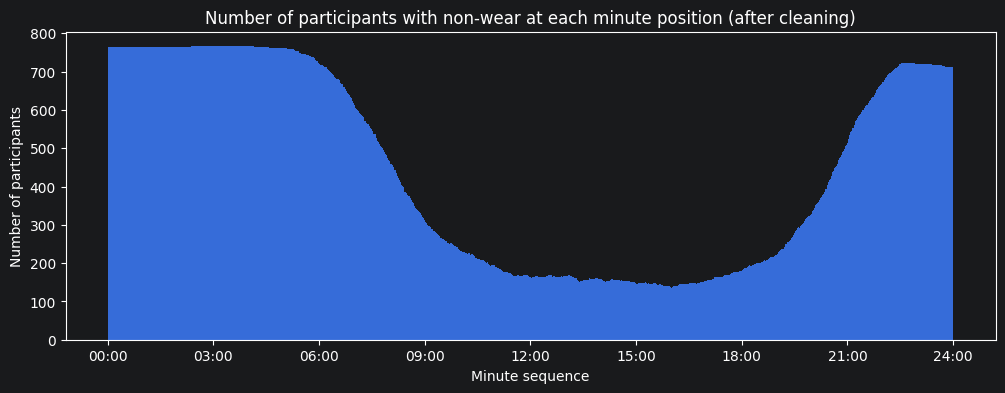

In [53]:
# non wear distribution plot after cleaning
non_wear_per_minute = (
    minute_metrics_08[minute_metrics_08["is_non_wear"] == True]
    .groupby("minute_sequence")["ID"]
    .nunique()
)

plt.figure(figsize=(12, 4))
plt.bar(non_wear_per_minute.index, non_wear_per_minute.values, width=1)
plt.xlabel("Minute sequence")
plt.ylabel("Number of participants")
plt.title("Number of participants with non-wear at each minute position (after cleaning)")
plt.xticks(
    ticks=[0, 180, 360, 540, 720, 900, 1080, 1260, 1440],
    labels=["00:00", "03:00", "06:00", "09:00", "12:00", "15:00", "18:00", "21:00", "24:00"],
)
plt.show()

## 4.3 Remove suspicious participant-days

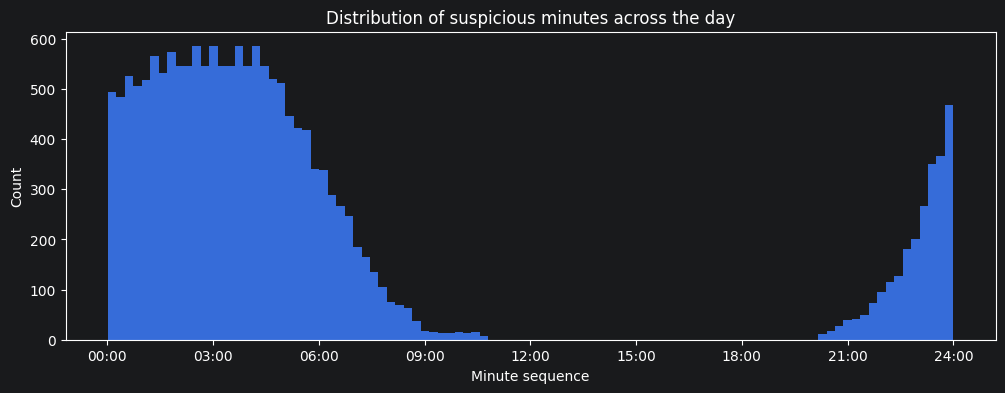

In [54]:
# Explore suspicious minutes distribution across the day

suspicious_minutes = (
    minute_metrics_08[
        minute_metrics_08["is_suspicious"] == True
    ]["minute_sequence"]
)

plt.figure(figsize=(12, 4))
plt.hist(suspicious_minutes, bins=100)
plt.xlabel("Minute sequence")
plt.ylabel("Count")
plt.title("Distribution of suspicious minutes across the day")
plt.xticks(
    ticks=[0, 180, 360, 540, 720, 900, 1080, 1260, 1440],
    labels=["00:00", "03:00", "06:00", "09:00", "12:00", "15:00", "18:00", "21:00", "24:00"],
)
plt.show()

In [55]:
# Drop only participant-days that contain any suspect minute, preserving each
# participant's remaining clean days. A single flagged minute is treated as
# compromising that day's rhythm fit, not the participant's entire record.

day_columns = ["ID", "study_day"]

suspect_participant_days = (
    minute_metrics_08.loc[minute_metrics_08["is_suspicious"] == True, day_columns]
    .drop_duplicates()
)

minutes_before = len(minute_metrics_08)
participants_before = minute_metrics_08["ID"].nunique()

# Anti-join: keep rows whose (ID, study day) is NOT in the suspect-day set.
minute_metrics_08 = (
    minute_metrics_08.merge(
        suspect_participant_days,
        on=day_columns,
        how="left",
        indicator=True,
    )
    .query("_merge == 'left_only'")
    .drop(columns="_merge")
    .copy()
)

print(f"Suspect participant-days removed: {len(suspect_participant_days):,}")
print(f"Minutes dropped: {minutes_before - len(minute_metrics_08):,}")
print(f"Participants before: {participants_before:,}")
print(f"Participants after:  {minute_metrics_08['ID'].nunique():,}")

Suspect participant-days removed: 57
Minutes dropped: 82,080
Participants before: 767
Participants after:  765


## 4.4 Remove days with implausible wear time
Drop days with less than 10 hours of wear wear time to ensure stable harmonic regression fits

In [56]:
wear_time_per_day = (
    minute_metrics_08
    .groupby(["ID", "study_day"])["is_non_wear"]
    .apply(lambda x: (x == False).sum() / 60)
    .reset_index()
    .rename(columns={"is_non_wear": "wear_hours"})
)

invalid_days = wear_time_per_day[
    (wear_time_per_day["wear_hours"] < 10)
][["ID", "study_day"]]

minute_metrics_08 = minute_metrics_08[
    ~minute_metrics_08.set_index(["ID", "study_day"]).index.isin(
        invalid_days.set_index(["ID", "study_day"]).index
    )
].reset_index(drop=True)

print(f"Dropped {len(invalid_days):,} days.")
print(f"Remaining participants: {minute_metrics_08['ID'].nunique():,}")

Dropped 282 days.
Remaining participants: 763


## 4.5 Remove participants with <4 valid days

remember to justify why a 4-day minimum

In [57]:
days_per_participant = (
    minute_metrics_08
    .groupby("ID")["study_day"]
    .nunique()
)

valid_participants = days_per_participant[days_per_participant >= 4].index

participants_before = minute_metrics_08["ID"].nunique()
minute_metrics_08 = minute_metrics_08[minute_metrics_08["ID"].isin(valid_participants)].reset_index(drop=True)
participants_after = minute_metrics_08["ID"].nunique()

print(f"Dropped {participants_before - participants_after:,} participants with fewer than 4 valid days.")
print(f"Remaining participants: {participants_after:,}")

Dropped 17 participants with fewer than 4 valid days.
Remaining participants: 746


### Compare IDs between summary metric and minute metric datasets to check for any discrepancies after cleaning

In [58]:
# compair daily_metrics and minute_metrics ID's
comparison_result = compare_dataframe_ids(
    first_dataframe=daily_metrics_08,
    second_dataframe=minute_metrics_08,
    id_column="ID",
)
print(f"Shared IDs: {len(comparison_result['in_both'])}")
print(f"Only in first: {len(comparison_result['only_in_first'])}")
print(f"Only in second: {len(comparison_result['only_in_second'])}")

Shared IDs: 746
Only in first: 680
Only in second: 0


### 4.6 Synchronize valid IDs across all dataframes

In [59]:
valid_ids_after_cleaning = set(minute_metrics_08["ID"].unique())

daily_metrics_08 = daily_metrics_08[
    daily_metrics_08["ID"].isin(valid_ids_after_cleaning)
].reset_index(drop=True)

# summary_metrics_08 uses ID as index at this point in the pipeline
summary_metrics_08 = summary_metrics_08[
    summary_metrics_08["ID"].isin(valid_ids_after_cleaning)
].reset_index(drop=True)

print(
    f"Participants after synchronisation:\n"
    f"  minute_metrics_08 : {minute_metrics_08['ID'].nunique():,}\n"
    f"  daily_metrics_08  : {daily_metrics_08['ID'].nunique():,}\n"
    f"  summary_metrics_08: {len(summary_metrics_08):,}"
)

Participants after synchronisation:
  minute_metrics_08 : 746
  daily_metrics_08  : 746
  summary_metrics_08: 746


# 5. Activity feature engineering

## 5.1 Bout structure

In [60]:
def calculate_bout_structure(
        minute_dataframe: pd.DataFrame,
) -> pd.DataFrame:
    """
    Calculate bout structure parameters for each participant and study day
    from minute-level accelerometer data.

    For each intensity level, the following parameters are calculated:
        - bout_count:          number of uninterrupted episodes per day
        - bout_mean_duration:  mean duration of episodes in minutes
        - bout_max_duration:   longest episode in minutes
        - bout_total_minutes:  total minutes accumulated in episodes

    Intensity levels calculated:
        - sedentary:  < 100 counts/min
        - light:      100–2019 counts/min
        - moderate:   2020–5998 counts/min
        - vigorous:   >= 5999 counts/min
        - mvpa:       moderate + vigorous (>= 2020 counts/min)
        - active:     light + moderate + vigorous (>= 100 counts/min)

    Non-wear and suspicious minutes are excluded before calculation.
    A bout is defined as consecutive minutes of the same intensity level
    with no tolerance for interruptions.
    """

    required_columns =[
        "ID",
        "study_day",
        "counts",
        "intensity_label",
        "is_non_wear",
        "is_suspicious",
    ]

    missing_columns = [
        column for column in required_columns
        if column not in minute_dataframe.columns
    ]

    if missing_columns:
        raise KeyError(
            f"The following required columns are missing: {missing_columns}"
        )

    intensity_level_definition = {
        "sedentary": lambda counts: counts < 100,
        "light": lambda counts: (counts >= 100) & (counts < 2020),
        "moderate": lambda counts: (counts >= 2020) & (counts < 5999),
        "vigorous": lambda counts: counts >= 5999,
        "mvpa": lambda counts: counts >= 2020,
        "active": lambda counts: counts >= 100,
    }

    valid_minutes = minute_dataframe[
        ~minute_dataframe["is_non_wear"]
        & ~minute_dataframe["is_suspicious"]
    ].copy()

    valid_minutes = valid_minutes.dropna(subset=["counts"])

    results = []

    for (participant_id, study_day), group in valid_minutes.groupby(["ID", "study_day"]
    ):
        day_result = {
            "ID": participant_id,
            "study_day": study_day,
        }

        for intensity_level, intensity_condition in intensity_level_definition.items():
            bout_duration = extract_bout_duration(
                counts=group["counts"],
                intensity_condition=intensity_condition,
            )

            if len(bout_duration) == 0:
                day_result[f"{intensity_level}_bout_count"] = 0
                day_result[f"{intensity_level}_bout_mean_duration"] = 0.0
                day_result[f"{intensity_level}_bout_max_duration"] = 0.0
                day_result[f"{intensity_level}_bout_total_minutes"] = 0.0
            else:
                day_result[f"{intensity_level}_bout_count"] = len(bout_duration)
                day_result[f"{intensity_level}_bout_mean_duration"] = np.mean(bout_duration)
                day_result[f"{intensity_level}_bout_max_duration"] = np.max(bout_duration)
                day_result[f"{intensity_level}_bout_total_minutes"] = np.sum(bout_duration)

        results.append(day_result)

    return pd.DataFrame(results)

def extract_bout_duration(
        counts: pd.Series,
        intensity_condition: callable
) -> list[int]:

    """
    Extract the duration of each uninterrupted bout matching the given
    intensity condition from a minute-level counts series.

    A bout is defined as a sequence of consecutive minutes where the
    intensity condition is met, with no tolerance for interruptions.
    """

    is_intensity = intensity_condition(counts).reset_index(drop=True)

    bout_durations = []
    current_bout_duration = 0

    for is_active in is_intensity:
        if is_active:
            current_bout_duration += 1
        else:
            if current_bout_duration > 0:
                bout_durations.append(current_bout_duration)
            current_bout_duration= 0
    if current_bout_duration > 0:
        bout_durations.append(current_bout_duration)

    return bout_durations

valid_minutes_check = minute_metrics_08[
    ~minute_metrics_08["is_non_wear"]
    & ~minute_metrics_08["is_suspicious"]
]

total_valid = len(valid_minutes_check)
sedentary_minutes = (valid_minutes_check["counts"] < 100).sum()
active_minutes = (valid_minutes_check["counts"] >= 100).sum()

print(f"Total valid minutes:             {total_valid}")
print(f"Sedentary minutes:               {sedentary_minutes}")
print(f"Active minutes:                  {active_minutes}")
print(f"Sum (should match total valid):  {sedentary_minutes + active_minutes}")
nan_count = valid_minutes_check["counts"].isna().sum()
print(f"NaN counts: {nan_count}")

result = calculate_bout_structure(minute_dataframe=minute_metrics_08)

Total valid minutes:             4663859
Sedentary minutes:               3177390
Active minutes:                  1486469
Sum (should match total valid):  4663859
NaN counts: 0


In [61]:
# calculate bout structure

bout_structure_daily = calculate_bout_structure(minute_dataframe=minute_metrics_08)

# merge into daily_metrics_08
daily_metrics_08 = daily_metrics_08.merge(
    bout_structure_daily,
    left_on=["ID", "V08PAStudyDay"],
    right_on=["ID", "study_day"],
    how="left",
)

# aggregate to summary level
bout_structure_summary = (
    bout_structure_daily
    .groupby("ID")
    .agg({
        col: "mean"
        for col in bout_structure_daily.columns
        if col not in ["ID", "study_day"]
    })
    .reset_index()
    .rename(columns={
        col: f"mean_{col}"
        for col in bout_structure_daily.columns
        if col not in ["ID", "study_day"]
    })
)

# merge into summary_metrics_08
summary_metrics_08 = summary_metrics_08.merge(
    bout_structure_summary,
    on="ID",
    how="left",
)

In [62]:
summary_metrics_08.to_csv(output_path / "summary_metrics_08.csv", sep="|", index=False)
daily_metrics_08.to_csv(output_path / "daily_metrics_08.csv", sep="|", index=False)

## 5.2 WHO guideline compliance

In [63]:
def calculate_who_guideline_compliance(daily_dataframe: pd.DataFrame) -> pd.DataFrame:
    """
    Calculate WHO guideline compliance for each day based on daily activity metrics.
    WHO guidelines for adults aged 18-64 recommend:
        - At least 150 minutes of moderate-intensity aerobic physical activity per week, or
        - At least 75 minutes of vigorous-intensity aerobic physical activity per week, or
        - An equivalent combination of moderate- and vigorous-intensity activity.

    This function adds a column to the daily_metrics_df indicating whether the
    participant met the WHO guidelines on that day.
    """

    required_columns = [
        "ID",
        "V08PAStudyDay",
        "V08DAYModMinT",
        "V08DAYVigMinT",
    ]

    missing_columns = [
        column for column in required_columns
        if column not in daily_dataframe.columns
    ]
    if missing_columns:
        raise KeyError(
            f"The following required columns are missing: {missing_columns}"
        )

    daily_moderate_guideline_threshold = 150/7
    daily_vigorous_guideline_threshold = 75/7
    weekly_moderate_guideline_threshold = 150
    weekly_vigorous_guideline_threshold = 75
    vigorous_to_moderate_multiplier = 2

    result_dataframe = daily_dataframe.copy()

    result_dataframe["combined_equivalent_minutes"] = (result_dataframe["V08DAYModMinT"] + result_dataframe["V08DAYVigMinT"] * vigorous_to_moderate_multiplier)

    result_dataframe["meets_daily_WHO_guideline"] = (
    (result_dataframe["V08DAYModMinT"] >= daily_moderate_guideline_threshold)
    | (result_dataframe["V08DAYVigMinT"] >= daily_vigorous_guideline_threshold)
    | (result_dataframe["combined_equivalent_minutes"] >= daily_moderate_guideline_threshold)
    )

    weekly_compliance = result_dataframe.groupby("ID").agg(
        total_moderate_minutes=("V08DAYModMinT", "sum"),
        total_vigorous_minutes=("V08DAYVigMinT", "sum"),
        total_combined_equivalent_minutes=("combined_equivalent_minutes", "sum"),
        day_count=("combined_equivalent_minutes", "count"),
    ).reset_index()

    weekly_compliance["meets_weekly_who_guideline"] = (
    (weekly_compliance["total_moderate_minutes"] / weekly_compliance["day_count"] * 7 >= weekly_moderate_guideline_threshold)
    | (weekly_compliance["total_vigorous_minutes"] / weekly_compliance["day_count"] * 7 >= weekly_vigorous_guideline_threshold)
    | (weekly_compliance["total_combined_equivalent_minutes"] / weekly_compliance["day_count"] * 7 >= weekly_moderate_guideline_threshold)
)

    weekly_compliance["weekly_guideline_gap_minutes"] = (
    weekly_compliance["total_combined_equivalent_minutes"] / weekly_compliance["day_count"] * 7
    - weekly_moderate_guideline_threshold
)
    result_dataframe = result_dataframe.merge(
        weekly_compliance[[
            "ID",
            "meets_weekly_who_guideline",
            "weekly_guideline_gap_minutes",
        ]],
        on="ID",
        how="left",
    )

    return result_dataframe

In [64]:
daily_metrics_08 = calculate_who_guideline_compliance(
    daily_dataframe=daily_metrics_08,
)

In [65]:
summary_metrics_08 = summary_metrics_08.merge(
    daily_metrics_08[["ID", "meets_weekly_who_guideline", "weekly_guideline_gap_minutes"]]
    .drop_duplicates(subset="ID"),
    on="ID",
    how="left",
)

In [66]:
summary_metrics_08["comparison"] = np.where(
    summary_metrics_08["V08ADHHS8"].isna()
    | summary_metrics_08["meets_weekly_who_guideline"].isna(),
    np.nan,
    (
        ((summary_metrics_08["V08ADHHS8"] == 1) & (summary_metrics_08["meets_weekly_who_guideline"] == True))
        | ((summary_metrics_08["V08ADHHS8"] == 0) & (summary_metrics_08["meets_weekly_who_guideline"] == False))

    ).map({True: "consistent", False: "inconsistent"}))

In [67]:
summary_metrics_08.to_csv(output_path / "summary_metrics_08.csv", sep="|", index=False)

In [68]:
participant_compliance = daily_metrics_08.groupby("ID")["meets_weekly_who_guideline"].first()

total = len(participant_compliance)
meets_true = participant_compliance.sum()
meets_false = total - meets_true

print(f"Total participants: {total}")
print(f"Meets WHO guideline: {meets_true} ({meets_true/total:.1%})")
print(f"Does not meet WHO guideline: {meets_false} ({meets_false/total:.1%})")

Total participants: 746
Meets WHO guideline: 239 (32.0%)
Does not meet WHO guideline: 507 (68.0%)


## 5.3 Activity onset / offset

In [69]:
def compute_activity_onset_offset_time(df: pd.DataFrame, id_col: str = "ID", day_col: str = "study_day",
                                       min_col: str = "minute_sequence", activity_count_col: str = "counts",
                                       suspect_col: str = "is_suspicious") -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    computes activity onset (first active minute) and activity offset (last active minute) per ID and day
    Returns:
        daily_activity_onset_offset_metrics: ID, Day, activity_onset_minute, activity_offset_minute, onset_time_hhmm, offset_time_hhmm
        id_agg_sctivity_onset_offset_metrics: ID, aggregated onset/offset mean and sds
    """

# function to convert minute of day to HH:MM format, minute 1 = 00:01, minute 1440 = 24:00

    def minute_to_hhmm(m):
        if pd.isna(m):
            return np.nan
        h = int((m - 1) // 60)
        mins = int((m - 1) % 60)
        return f"{h:02d}:{mins:02d}"

    results = []

# filter per ID and day, only non-suspect minutes, sort by minute sequence, find first and last active minute (activity count > 0)

    for (id, day), grp in df.groupby([id_col, day_col]):

        grp_filtered = grp[grp[suspect_col] == 0].sort_values(min_col)
        active = grp_filtered[grp_filtered[activity_count_col] > 0][min_col].values

        if len(active) == 0:
            results.append({
                id_col: id,
                day_col: day,
                "activity_onset_minute": np.nan,
                "activity_offset_minute": np.nan,
            })
            continue

        results.append({
            id_col: id,
            day_col: day,
            "activity_onset_minute": active[0],  # first active minute
            "activity_offset_minute": active[-1],  # last active minute
        })

    daily_activity_onset_offset_metrics = pd.DataFrame(results)

    daily_activity_onset_offset_metrics["onset_time_hhmm"] = daily_activity_onset_offset_metrics["activity_onset_minute"].apply(minute_to_hhmm)
    daily_activity_onset_offset_metrics["offset_time_hhmm"] = daily_activity_onset_offset_metrics["activity_offset_minute"].apply(minute_to_hhmm)
    daily_activity_onset_offset_metrics["wear_duration_min"] = daily_activity_onset_offset_metrics["activity_offset_minute"] - daily_activity_onset_offset_metrics["activity_onset_minute"]

    # aggregate per ID across days

    id_agg_activity_onset_offset_metrics = (
        daily_activity_onset_offset_metrics.groupby(id_col).agg(
            activity_onset_minute_mean=("activity_onset_minute", np.mean),
            activity_onset_minute_sd=("activity_onset_minute", np.std),
            activity_offset_minute_mean=("activity_offset_minute", np.mean),
            activity_offset_minute_sd=("activity_offset_minute", np.std),
            wear_duration_mean=("wear_duration_min", np.mean),
            valid_days_derived=("activity_onset_minute", "count"),
        )
        .reset_index()
    )

    id_agg_activity_onset_offset_metrics["onset_mean_hhmm"] = id_agg_activity_onset_offset_metrics["activity_onset_minute_mean"].apply(minute_to_hhmm)
    id_agg_activity_onset_offset_metrics["offset_mean_hhmm"] = id_agg_activity_onset_offset_metrics["activity_offset_minute_mean"].apply(minute_to_hhmm)

    return daily_activity_onset_offset_metrics, id_agg_activity_onset_offset_metrics

In [70]:
daily_activity_onset_offset_metrics_08, id_agg_activity_onset_offset_metrics_08 = compute_activity_onset_offset_time(minute_metrics_08)
summary_metrics_08 = summary_metrics_08.merge(id_agg_activity_onset_offset_metrics_08, on="ID", how="left")
daily_metrics_08 = daily_metrics_08.merge(daily_activity_onset_offset_metrics_08, on=["ID", "study_day"], how="left")

In [71]:
summary_metrics_08.to_csv(output_path / "summary_metrics_08.csv", sep="|", index=False)
daily_metrics_08.to_csv(output_path / "daily_metrics_08.csv", sep="|", index=False)

## 5.4 Valid-day discrepancy exploration

In [72]:
discrepant = summary_metrics_08[
    summary_metrics_08["valid_days_derived"] != summary_metrics_08["valid_days_oai"]
][["ID", "valid_days_derived", "valid_days_oai", "wear_duration_mean"]].dropna()

print(f"Number of discrepant participants: {len(discrepant)}")
print(discrepant.sort_values("ID"))
print(discrepant.shape)

# separately check how many have mean wear duration under 600 minutes (10 hours)
under_600 = discrepant[discrepant["wear_duration_mean"] < 600]
print(f"\nParticipants with mean wear duration under 600 minutes: {len(under_600)}")
print(under_600.sort_values("wear_duration_mean"))
print(under_600.shape)

# check suspicious minutes for discrepant participants
discrepant_ids = discrepant["ID"].tolist()

suspicious_summary = (
    minute_metrics_08[minute_metrics_08["ID"].isin(discrepant_ids)]
    .groupby("ID")["is_suspicious"]
    .agg(
        total_minutes="count",
        suspicious_minutes="sum",
    )
    .assign(
        suspicious_percent=lambda x: (x["suspicious_minutes"] / x["total_minutes"] * 100).round(1)
    )
    .reset_index()
)

discrepant = discrepant.merge(suspicious_summary, on="ID", how="left")

print(f"\nDiscrepant participants with suspicious minutes:")
print(discrepant[discrepant["suspicious_minutes"] > 0].sort_values("suspicious_minutes", ascending=False))
print(discrepant[discrepant["suspicious_minutes"] > 0].sort_values("suspicious_minutes", ascending=False).shape)
print(f"\nDiscrepant participants without suspicious minutes:")
print(discrepant[discrepant["suspicious_minutes"] == 0].sort_values("ID"))
print(discrepant[discrepant["suspicious_minutes"] == 0].sort_values("ID").shape)

# participants that are both suspicious AND under 600 minutes wear duration
print(f"\nDiscrepant participants with suspicious minutes AND under 600 minutes wear duration:")
suspicious_and_under_600 = discrepant[
    (discrepant["suspicious_minutes"] > 0)
    & (discrepant["wear_duration_mean"] < 600)
]
print(suspicious_and_under_600.sort_values("wear_duration_mean"))
print(suspicious_and_under_600.shape)


Number of discrepant participants: 106
          ID  valid_days_derived  valid_days_oai  wear_duration_mean
2    9004669                   9             7.0         1143.666667
15   9021428                   7             6.0          880.571429
22   9033275                   8             7.0         1015.875000
23   9033937                   7             6.0         1059.857143
24   9034963                   5             7.0          948.600000
..       ...                 ...             ...                 ...
690  9921811                  12             7.0          950.416667
724  9974327                   7             6.0         1070.142857
732  9982186                   5             7.0         1149.600000
737  9988305                  12             7.0          898.833333
740  9990355                   7             6.0          874.142857

[106 rows x 4 columns]
(106, 4)

Participants with mean wear duration under 600 minutes: 0
Empty DataFrame
Columns: [ID, valid_days_

In [73]:
print(summary_metrics_08[summary_metrics_08["valid_days_derived"] > 7].shape)

(37, 70)


In [74]:
# count all days per participant from minute data
all_days_from_minutes = (
    minute_metrics_08
    .groupby("ID")["study_day"]
    .nunique()
    .reset_index()
    .rename(columns={"study_day": "total_days_minute_data"})
)

# count valid days per participant from minute data
# a day is valid if it has at least one non-suspicious, non-wear minute
valid_days_from_minutes = (
    minute_metrics_08[
        ~minute_metrics_08["intensity_label"].isin(["non_wear", "suspicious"])
    ]
    .groupby("ID")["study_day"]
    .nunique()
    .reset_index()
    .rename(columns={"study_day": "valid_days_minute_data"})
)

# count days per participant from daily data (OAI valid days)
oai_valid_days = (
    daily_metrics_08
    .groupby("ID")["V08PAStudyDay"]
    .nunique()
    .reset_index()
    .rename(columns={"V08PAStudyDay": "oai_valid_days"})
)

# merge all three together with valid_days_oai from summary
day_comparison = (
    summary_metrics_08[["ID", "valid_days_oai"]]
    .merge(all_days_from_minutes, on="ID", how="left")
    .merge(valid_days_from_minutes, on="ID", how="left")
    .merge(oai_valid_days, on="ID", how="left")
)

# add difference columns to understand exclusion reasons
day_comparison["days_excluded_total"] = (
    day_comparison["total_days_minute_data"] - day_comparison["oai_valid_days"]
)
day_comparison["days_excluded_nonwear_or_suspicious"] = (
    day_comparison["total_days_minute_data"] - day_comparison["valid_days_minute_data"]
)
day_comparison["days_excluded_oai_cap"] = (
    day_comparison["valid_days_minute_data"] - day_comparison["oai_valid_days"]
)

print(f"Total participants: {len(day_comparison)}")
print(f"\nDay comparison statistics:")
print(day_comparison[[
    "total_days_minute_data",
    "valid_days_minute_data",
    "oai_valid_days",
    "valid_days_oai",
    "days_excluded_total",
    "days_excluded_nonwear_or_suspicious",
    "days_excluded_oai_cap",
]].describe())

print(f"\nParticipants with discrepancies:")
discrepant = day_comparison[
    day_comparison["valid_days_minute_data"] != day_comparison["oai_valid_days"]
].dropna()
print(f"Total discrepant: {len(discrepant)}")
print(discrepant.sort_values("days_excluded_total", ascending=False))

Total participants: 746

Day comparison statistics:
       total_days_minute_data  valid_days_minute_data  oai_valid_days  \
count              746.000000              746.000000      746.000000   
mean                 6.821716                6.821716        6.676944   
std                  0.771374                0.771374        0.726436   
min                  4.000000                4.000000        3.000000   
25%                  7.000000                7.000000        7.000000   
50%                  7.000000                7.000000        7.000000   
75%                  7.000000                7.000000        7.000000   
max                 12.000000               12.000000        7.000000   

       valid_days_oai  days_excluded_total  \
count      746.000000           746.000000   
mean         6.676944             0.144772   
std          0.726436             0.613456   
min          3.000000            -3.000000   
25%          7.000000             0.000000   
50%          7

In [75]:
# get day-level data for discrepant participants
discrepant_ids = discrepant["ID"].tolist()

# get all days from minute data for discrepant participants
discrepant_days = daily_activity_onset_offset_metrics_08[
    daily_activity_onset_offset_metrics_08["ID"].isin(discrepant_ids)
][["ID", "study_day", "wear_duration_min"]]

# add suspicious minutes per day
suspicious_per_day = (
    minute_metrics_08[minute_metrics_08["ID"].isin(discrepant_ids)]
    .groupby(["ID", "study_day"])["is_suspicious"]
    .sum()
    .reset_index()
    .rename(columns={"study_day": "study_day", "is_suspicious": "suspicious_minutes"})
)

discrepant_days = discrepant_days.merge(suspicious_per_day, on=["ID", "study_day"], how="left")

# flag days that are in minute data but NOT in daily_metrics_08 (excluded by OAI)
oai_days = daily_metrics_08[["ID", "study_day"]].drop_duplicates()
oai_days["in_oai_daily"] = True

discrepant_days = discrepant_days.merge(oai_days, on=["ID", "study_day"], how="left")
discrepant_days["in_oai_daily"] = discrepant_days["in_oai_daily"].fillna(False)

# only look at excluded days
excluded_days = discrepant_days[discrepant_days["in_oai_daily"] == False]

print(f"Total excluded days across discrepant participants: {len(excluded_days)}")
print(f"\nExclusion reasons:")
print(f"Days with suspicious minutes > 0: {(excluded_days['suspicious_minutes'] > 0).sum()} ({(excluded_days['suspicious_minutes'] > 0).mean():.1%})")
print(f"Days with wear duration < 600 min: {(excluded_days['wear_duration_min'] < 600).sum()} ({(excluded_days['wear_duration_min'] < 600).mean():.1%})")
print(f"Days with both suspicious AND < 600 min: {((excluded_days['suspicious_minutes'] > 0) & (excluded_days['wear_duration_min'] < 600)).sum()}")
print(f"Days with neither reason (OAI 7-day cap): {((excluded_days['suspicious_minutes'] == 0) & (excluded_days['wear_duration_min'] >= 600)).sum()}")

Total excluded days across discrepant participants: 132

Exclusion reasons:
Days with suspicious minutes > 0: 0 (0.0%)
Days with wear duration < 600 min: 0 (0.0%)
Days with both suspicious AND < 600 min: 0
Days with neither reason (OAI 7-day cap): 132


## 5.5 Harmonic regression

five features per participant.
Three from harmonic regression (MESOR, amplitude, acrophase) describing
the *shape* of the average daily rhythm. Two nonparametric indices
(IV, IS) describing within-day fragmentation and between-day consistency,
which the harmonic fit cannot capture by construction.

### 5.5.1 Mean daily curve

In [76]:
# gropupby ID, minute_sequence

mean_daily_curve = (
    minute_metrics_08
    .groupby(["ID", "minute_sequence"])["counts"]
    .mean()
    .reset_index()
    .rename(columns={"counts": "mean_counts"})
)

print(f"Mean daily curve computed for {mean_daily_curve['ID'].nunique():,} participants.")
print(mean_daily_curve.head())

Mean daily curve computed for 746 participants.
        ID  minute_sequence  mean_counts
0  9002817                1          0.0
1  9002817                2          0.0
2  9002817                3          0.0
3  9002817                4          0.0
4  9002817                5          0.0


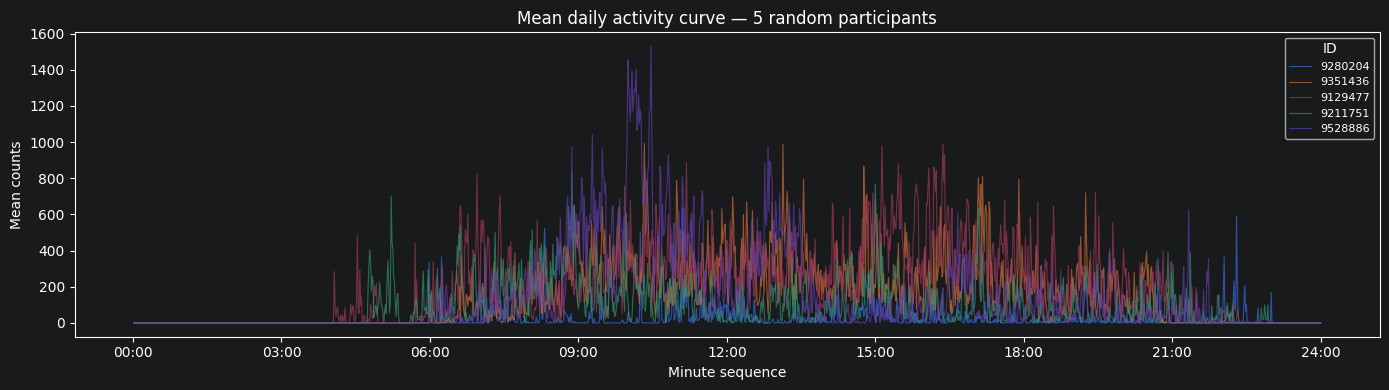

In [77]:
# Plot mean daily curve for a few random participants to verify the shape (sanity check)

sample_ids = mean_daily_curve["ID"].drop_duplicates().sample(5, random_state=42)

fig, ax = plt.subplots(figsize=(14, 4))

for participant_id in sample_ids:
    participant_curve = mean_daily_curve[mean_daily_curve["ID"] == participant_id]
    ax.plot(
        participant_curve["minute_sequence"],
        participant_curve["mean_counts"],
        alpha=0.7,
        linewidth=0.8,
        label=str(participant_id),
    )

ax.set_xlabel("Minute sequence")
ax.set_ylabel("Mean counts")
ax.set_title("Mean daily activity curve — 5 random participants")
ax.set_xticks([0, 180, 360, 540, 720, 900, 1080, 1260, 1440])
ax.set_xticklabels(["00:00", "03:00", "06:00", "09:00", "12:00", "15:00", "18:00", "21:00", "24:00"])
ax.legend(title="ID", fontsize=8)
plt.tight_layout()
plt.show()

### 5.5.2 Single-participant demonstration

intercept (MESOR) plus two harmonic
pairs at periods of 24h and 12h, fitted with ordinary least squares.
Note that acrophase is read from argmax of the fitted curve rather
than from arctan2 of the coefficients to avoid sign-convention bugs.

In [78]:
# manual fit for single participant

participant_id = 9002817

single_curve = mean_daily_curve[mean_daily_curve["ID"] == participant_id]

minutes = single_curve["minute_sequence"].to_numpy(dtype=float)
counts = single_curve["mean_counts"].to_numpy(dtype=float)

# Build design matrix: intercept + 2 harmonic pairs
period = 1440
design_matrix = np.column_stack([
    np.ones(len(minutes)),                                    # MESOR
    np.cos(2 * np.pi * 1 * minutes / period),                # harmonic 1 cosine
    np.sin(2 * np.pi * 1 * minutes / period),                # harmonic 1 sine
    np.cos(2 * np.pi * 2 * minutes / period),                # harmonic 2 cosine
    np.sin(2 * np.pi * 2 * minutes / period),                # harmonic 2 sine
])

coefficients, _, _, _ = lstsq(design_matrix, counts, rcond=None)

mesor = coefficients[0]
amplitude = np.sqrt(coefficients[1]**2 + coefficients[2]**2)
# Read acrophase directly from the peak of the fitted curve
# rather than computing from arctan2 to avoid sign convention issues
fitted_counts = design_matrix @ coefficients
peak_minute = minutes[np.argmax(fitted_counts)]
acrophase_hours = peak_minute / 60

print(f"MESOR: {mesor:.2f}")
print(f"Amplitude: {amplitude:.2f}")
print(f"Acrophase: {acrophase_hours:.2f} hours ({int(peak_minute // 60):02d}:{int(peak_minute % 60):02d})")

MESOR: 137.54
Amplitude: 153.02
Acrophase: 9.25 hours (09:15)


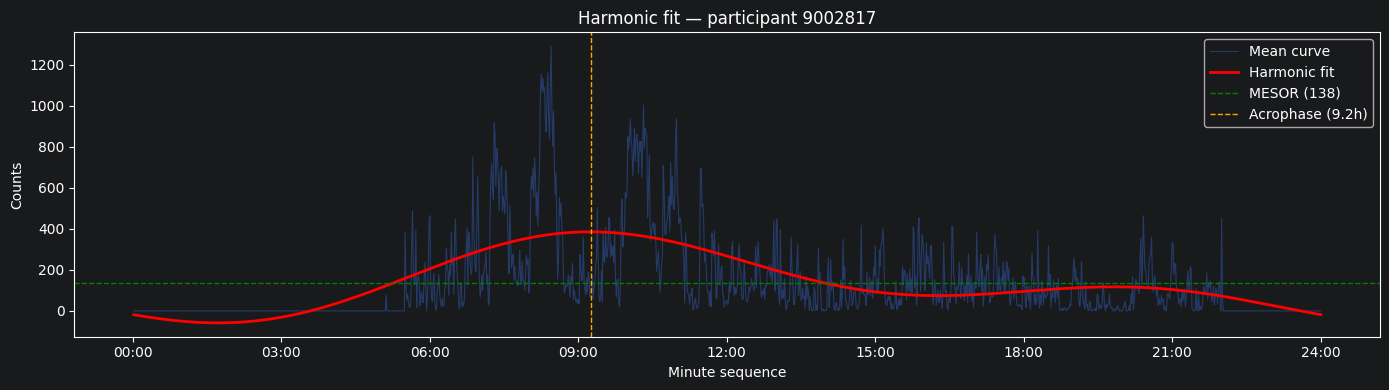

In [79]:
# plot showing curve, fit, MESOR line, acrophase line

fitted_counts = design_matrix @ coefficients

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(minutes, counts, alpha=0.4, linewidth=0.8, label="Mean curve")
ax.plot(minutes, fitted_counts, linewidth=2, color="red", label="Harmonic fit")
ax.axhline(y=mesor, color="green", linestyle="--", linewidth=1, label=f"MESOR ({mesor:.0f})")
ax.axvline(x=acrophase_hours * 60, color="orange", linestyle="--", linewidth=1, label=f"Acrophase ({acrophase_hours:.1f}h)")
ax.set_xlabel("Minute sequence")
ax.set_ylabel("Counts")
ax.set_title(f"Harmonic fit — participant {participant_id}")
ax.set_xticks([0, 180, 360, 540, 720, 900, 1080, 1260, 1440])
ax.set_xticklabels(["00:00", "03:00", "06:00", "09:00", "12:00", "15:00", "18:00", "21:00", "24:00"])
ax.legend()
plt.tight_layout()
plt.show()


### 5.5.3 Fit to all participants (MESOR, amplitude, acrophase)

In [80]:
# fit_harmonic_model function

def fit_harmonic_model(
        mean_daily_curve: pd.DataFrame,
        column_id: str,
        column_minute_sequence: str,
        column_mean_counts: str,
        period: int = 1440,
        number_of_harmonics: int = 2,
) -> pd.DataFrame:

    # Fit a harmonic regression model to each participant's mean daily curve and extract MESOR, amplitude, and acrophase.

    records = []

    for participant_id, participant_curve in mean_daily_curve.groupby(column_id):
        minutes = participant_curve[column_minute_sequence].to_numpy(dtype=float)
        counts = participant_curve[column_mean_counts].to_numpy(dtype=float)

        # Build design matrix
        design_matrix = [np.ones(len(minutes))]
        for harmonic_index in range(1, number_of_harmonics + 1):
            design_matrix.append(np.cos(2 * np.pi * harmonic_index * minutes / period))
            design_matrix.append(np.sin(2 * np.pi * harmonic_index * minutes / period))
        design_matrix = np.column_stack(design_matrix)

        coefficients, _, _, _ = lstsq(design_matrix, counts, rcond=None)

        mesor = coefficients[0]
        amplitude = np.sqrt(coefficients[1]**2 + coefficients[2]**2)

        fitted_counts = design_matrix @ coefficients
        peak_minute = minutes[np.argmax(fitted_counts)]
        acrophase_hour = peak_minute /60

        records.append({
            column_id: participant_id,
            "mesor":mesor,
            "amplitude":amplitude,
            "acrophase":acrophase_hour,
        })

    return pd.DataFrame(records).set_index(column_id)

harmonic_features = fit_harmonic_model(
    mean_daily_curve = mean_daily_curve,
    column_id = "ID",
    column_minute_sequence = "minute_sequence",
    column_mean_counts = "mean_counts",
)

print(f"Harmonic features extracted for {len(harmonic_features)} participants:")
print(harmonic_features.describe())


Harmonic features extracted for 746 participants:
            mesor   amplitude   acrophase
count  746.000000  746.000000  746.000000
mean   148.459793  156.275457   12.580585
std     75.351410   88.600776    2.988000
min      4.088773    6.276765    4.733333
25%     92.824231   94.036376   10.383333
50%    134.764931  136.938647   12.116667
75%    189.721677  197.017011   14.612500
max    554.354977  761.262204   20.333333


### 5.5.4 Acrophase distribution / outlier inspection

describe what an extreme acrophase means (needs to be done) — peak before 6am
    or after 8pm is unusual and worth visual inspection. Document the
    decision: keep

In [81]:
# find participants with acrophase < 6 or > 20

print(harmonic_features[harmonic_features["acrophase"] < 6])
print(harmonic_features[harmonic_features["acrophase"] > 20])

              mesor   amplitude  acrophase
ID                                        
9120358  332.325231  145.517999   4.733333
9613942  155.061409  152.585073   5.183333
9652894  244.959921  143.141685   5.966667
9903777  192.409167  116.677781   5.566667
              mesor   amplitude  acrophase
ID                                        
9635414  126.618287  106.163791  20.016667
9677734  152.843948  111.442426  20.333333


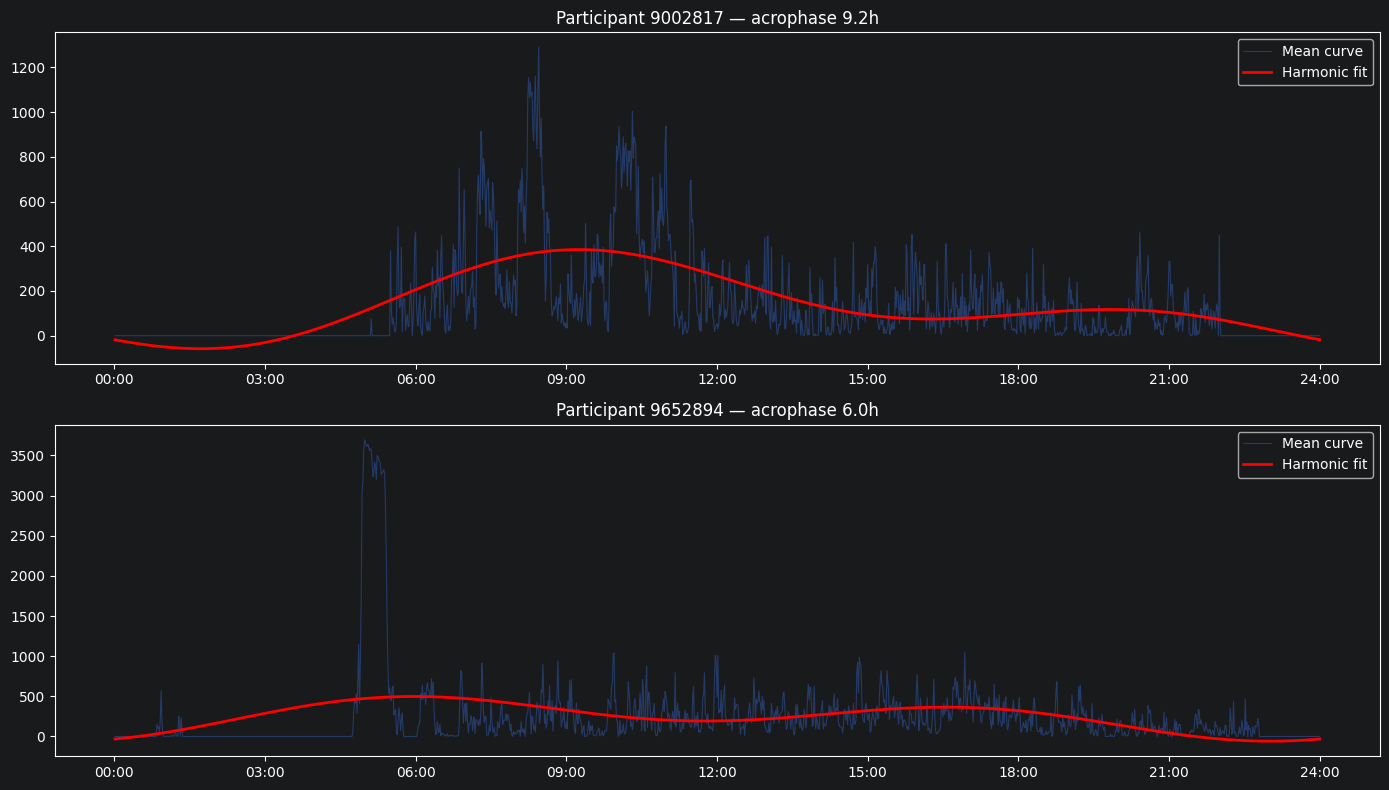

In [82]:
# Plot two outlier examples

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(14, 8))

for ax, participant_id in zip(axes, [9002817, 9652894]):
    participant_curve = mean_daily_curve[mean_daily_curve["ID"] == participant_id]
    minutes = participant_curve["minute_sequence"].to_numpy(dtype=float)
    counts = participant_curve["mean_counts"].to_numpy(dtype=float)

    design_matrix = np.column_stack([
        np.ones(len(minutes)),
        np.cos(2 * np.pi * 1 * minutes / 1440),
        np.sin(2 * np.pi * 1 * minutes / 1440),
        np.cos(2 * np.pi * 2 * minutes / 1440),
        np.sin(2 * np.pi * 2 * minutes / 1440),
    ])
    coefficients, _, _, _ = lstsq(design_matrix, counts, rcond=None)
    fitted_counts = design_matrix @ coefficients

    ax.plot(minutes, counts, alpha=0.4, linewidth=0.8, label="Mean curve")
    ax.plot(minutes, fitted_counts, linewidth=2, color="red", label="Harmonic fit")
    ax.set_title(f"Participant {participant_id} — acrophase {harmonic_features.loc[participant_id, 'acrophase']:.1f}h")
    ax.set_xticks([0, 180, 360, 540, 720, 900, 1080, 1260, 1440])
    ax.set_xticklabels(["00:00", "03:00", "06:00", "09:00", "12:00", "15:00", "18:00", "21:00", "24:00"])
    ax.legend()

plt.tight_layout()
plt.show()

## 5.6 Rhythm indices: Intradaily Variability (IV) and Interdaily Stability (IS)

Harmonic regression describes the *shape* of the daily activity rhythm (when does
the person peak, how active are they on average). IV and IS describe two complementary
dimensions that harmonic parameters cannot capture:

IV: Within-day fragmentation — how much does the person's activity fluctuate up and down across the day?
    - High IV = lots of short bursts of activity interspersed with rest (frequent stop-and-go pattern)
    - Low IV = more consolidated activity and rest periods (smooth, sustained activity pattern)

IS: Day-to-day consistency — how similar is the person's activity pattern across different days?
    - High IS = very regular routine, similar activity levels at the same times each day
    - Low IS = irregular routine, varying activity levels and timing across days

Technical note
IV and IS are computed from the **raw minute-level data across all valid days**,
not from the mean daily curve. This is intentional, both indices specifically
quantify variability over time, which the mean curve averages away by design.

### 5.6.1 IV / IS single-participant demonstration

In [83]:
participant_id = 9002817

participant_data = (
    minute_metrics_08[minute_metrics_08["ID"] == participant_id]
    .sort_values(["study_day", "minute_sequence"])
)

counts = participant_data["counts"].to_numpy(dtype=float)

# IV: ratio of mean squared first-order differences to overall variance
# n * sum of squared differences between consecutive minutes
# divided by (n-1) * overall variance
number_of_minutes = len(counts)
overall_mean = np.mean(counts)
overall_variance = np.sum((counts - overall_mean) ** 2)
squared_differences = np.sum(np.diff(counts) ** 2)

iv = (number_of_minutes * squared_differences) / ((number_of_minutes - 1) * overall_variance)

print(f"IV for participant {participant_id}: {iv:.4f}")

IV for participant 9002817: 0.4082


In [84]:
# IS: ratio of variance of the mean 24h profile to overall variance
# Reshape counts into a matrix of days x minutes
number_of_complete_days = len(counts) // 1440
trimmed_counts = counts[:number_of_complete_days * 1440]
reshaped = trimmed_counts.reshape(number_of_complete_days, 1440)

# Mean activity at each of the 1440 minute positions across all days
mean_24h_profile = np.mean(reshaped, axis=0)
overall_mean = np.mean(trimmed_counts)

profile_variance = np.sum((mean_24h_profile - overall_mean) ** 2)
overall_variance = np.sum((trimmed_counts - overall_mean) ** 2)

is_index = (number_of_complete_days * profile_variance) / overall_variance

print(f"IS for participant {participant_id}: {is_index:.4f}")

IS for participant 9002817: 0.2429


### 5.6.2 Apply IV / IS to all participants

In [85]:
# compute_iv_and_is function
def compute_iv_and_is(
    minute_dataframe: pd.DataFrame,
    column_id: str,
    column_study_day: str,
    column_minute_sequence: str,
    column_counts: str,
    minutes_per_day: int = 1440,
) -> pd.DataFrame:
    """
    Compute intradaily variability (IV) and interdaily stability (IS)
    for each participant from the raw minute-level activity data.

    IV and IS are computed from the raw multi-day signal rather than
    the mean daily curve because both indices specifically quantify
    variability over time, which the mean curve averages away.

    :param minute_dataframe: Cleaned minute-level DataFrame.
    :param column_id: Participant identifier column.
    :param column_study_day: Study day column.
    :param column_minute_sequence: Minute sequence column.
    :param column_counts: Activity counts column.
    :param minutes_per_day: Number of minutes per day (1440).
    :return: DataFrame indexed by participant ID with columns
        [intradaily_variability, interdaily_stability].
    """
    records = []

    for participant_id, participant_data in minute_dataframe.groupby(column_id):
        participant_data = participant_data.sort_values(
            by=[column_study_day, column_minute_sequence]
        )
         # Fill residual NaN values with 0 before computing variance-based indices
        counts = participant_data[column_counts].to_numpy(dtype=float)
        counts = np.nan_to_num(counts, nan=0.0)

        number_of_minutes = len(counts)
        overall_mean = np.mean(counts)
        overall_variance = np.sum((counts - overall_mean) ** 2)

        # IV
        squared_differences = np.sum(np.diff(counts) ** 2)
        iv = (number_of_minutes * squared_differences) / ((number_of_minutes - 1) * overall_variance)

        # IS
        number_of_complete_days = number_of_minutes // minutes_per_day
        trimmed_counts = counts[:number_of_complete_days * minutes_per_day]
        reshaped = trimmed_counts.reshape(number_of_complete_days, minutes_per_day)
        mean_24h_profile = np.mean(reshaped, axis=0)
        overall_mean_trimmed = np.mean(trimmed_counts)
        profile_variance = np.sum((mean_24h_profile - overall_mean_trimmed) ** 2)
        overall_variance_trimmed = np.sum((trimmed_counts - overall_mean_trimmed) ** 2)
        is_index = (number_of_complete_days * profile_variance) / overall_variance_trimmed

        records.append({
            column_id: participant_id,
            "intradaily_variability": iv,
            "interdaily_stability": is_index,
        })

    return pd.DataFrame(records).set_index(column_id)

# apply function
rhythm_indices = compute_iv_and_is(
    minute_dataframe=minute_metrics_08,
    column_id="ID",
    column_study_day="study_day",
    column_minute_sequence="minute_sequence",
    column_counts="counts",
)

# describe IV an IS
print(f"IV and IS computed for {len(rhythm_indices)} participants.")
print(rhythm_indices.describe())

IV and IS computed for 746 participants.
       intradaily_variability  interdaily_stability
count              746.000000            746.000000
mean                 0.628693              0.229495
std                  0.242734              0.057077
min                  0.064418              0.119354
25%                  0.447848              0.193536
50%                  0.644423              0.220059
75%                  0.816305              0.252298
max                  1.382949              0.782931


Merge features into the summary metrics_08

In [86]:
summary_metrics_08 = summary_metrics_08.set_index("ID")

summary_metrics_08 = summary_metrics_08.join(harmonic_features, how="left")
summary_metrics_08 = summary_metrics_08.join(rhythm_indices, how="left")

print(f"Summary data shape after merging: {summary_metrics_08.shape}")
print(f"Missing values for new features:")
print(summary_metrics_08[["mesor", "amplitude", "acrophase",
                           "intradaily_variability", "interdaily_stability"]].isna().sum())

Summary data shape after merging: (746, 74)
Missing values for new features:
mesor                     0
amplitude                 0
acrophase                 0
intradaily_variability    0
interdaily_stability      0
dtype: int64


## 5.7 Per-day harmonic decomposition

In [87]:
# define weekend days and weekday days

weekend_days = ["Saturday", "Sunday"]
daily_metrics_08["day_type"] = daily_metrics_08["week_day"].apply(
    lambda day: "weekend" if day in weekend_days else "weekday"
)

### 5.7.1 Single-day demonstration

In [88]:
participant_id = 9002817
study_day = 981

single_day = (
    minute_metrics_08[
        (minute_metrics_08["ID"] == participant_id) &
        (minute_metrics_08["study_day"] == study_day)
    ]
    .sort_values("minute_sequence")
)

minutes = single_day["minute_sequence"].to_numpy(dtype=float)
counts = single_day["counts"].to_numpy(dtype=float)
counts = np.nan_to_num(counts, nan=0.0)

# Harmonic model
period = 1440
design_matrix = np.column_stack([
    np.ones(len(minutes)),
    np.cos(2 * np.pi * 1 * minutes / period),
    np.sin(2 * np.pi * 1 * minutes / period),
    np.cos(2 * np.pi * 2 * minutes / period),
    np.sin(2 * np.pi * 2 * minutes / period),
])

coefficients, _, _, _ = lstsq(design_matrix, counts, rcond=None)
fitted_counts = design_matrix @ coefficients

mesor = coefficients[0]
amplitude = np.sqrt(coefficients[1]**2 + coefficients[2]**2)
peak_minute = minutes[np.argmax(fitted_counts)]
acrophase_hours = peak_minute / 60

# IV
number_of_minutes = len(counts)
overall_mean = np.mean(counts)
overall_variance = np.sum((counts - overall_mean) ** 2)
squared_differences = np.sum(np.diff(counts) ** 2)
iv = (number_of_minutes * squared_differences) / ((number_of_minutes - 1) * overall_variance)

print(f"MESOR: {mesor:.2f}")
print(f"Amplitude: {amplitude:.2f}")
print(f"Acrophase: {acrophase_hours:.2f}h")
print(f"IV: {iv:.4f}")

MESOR: 113.02
Amplitude: 104.99
Acrophase: 8.82h
IV: 0.6366


### 5.7.2 Per-day harmonic + IV across all participant-days

same harmonic specification as section 2, but fitted to each participant-day independently rather than to the mean curve

In [89]:
# harmonic regression features and iv function

def extract_daily_harmonic_and_iv(
    minute_dataframe: pd.DataFrame,
    column_id: str,
    column_study_day: str,
    column_minute_sequence: str,
    column_counts: str,
    period: int = 1440,
    number_of_harmonics: int = 2,
) -> pd.DataFrame:
    """
    Fit harmonic regression and compute intradaily variability (IV)
    for each participant-day.

    Unlike the participant-level harmonic features which are fitted to the
    mean daily curve, these features are computed per individual day to enable
    weekday vs weekend and employment status comparisons.

    IS is excluded here as it requires multiple days by definition and
    remains a participant-level feature only.

    :param minute_dataframe: Cleaned minute-level DataFrame.
    :param column_id: Participant identifier column.
    :param column_study_day: Study day column.
    :param column_minute_sequence: Minute sequence column.
    :param column_counts: Activity counts column.
    :param period: Period in minutes (1440 for daily rhythm).
    :param number_of_harmonics: Number of harmonic pairs to fit.
    :return: DataFrame with one row per participant-day containing
        mesor, amplitude, acrophase, and intradaily_variability.
    """
    records = []

    for (participant_id, study_day), day_data in minute_dataframe.groupby(
        [column_id, column_study_day]
    ):
        day_data = day_data.sort_values(column_minute_sequence)
        minutes = day_data[column_minute_sequence].to_numpy(dtype=float)
        counts = np.nan_to_num(
            day_data[column_counts].to_numpy(dtype=float), nan=0.0
        )

        # Build design matrix
        design_matrix = [np.ones(len(minutes))]
        for harmonic_index in range(1, number_of_harmonics + 1):
            design_matrix.append(np.cos(2 * np.pi * harmonic_index * minutes / period))
            design_matrix.append(np.sin(2 * np.pi * harmonic_index * minutes / period))
        design_matrix = np.column_stack(design_matrix)

        coefficients, _, _, _ = lstsq(design_matrix, counts, rcond=None)
        fitted_counts = design_matrix @ coefficients

        mesor = coefficients[0]
        amplitude = np.sqrt(coefficients[1]**2 + coefficients[2]**2)
        peak_minute = minutes[np.argmax(fitted_counts)]
        acrophase_hours = peak_minute / 60

        # IV
        number_of_minutes = len(counts)
        overall_mean = np.mean(counts)
        overall_variance = np.sum((counts - overall_mean) ** 2)
        squared_differences = np.sum(np.diff(counts) ** 2)
        iv = (
            (number_of_minutes * squared_differences)
            / ((number_of_minutes - 1) * overall_variance)
            if overall_variance > 0 else np.nan
        )

        records.append({
            column_id: participant_id,
            column_study_day: study_day,
            "mesor_daily": mesor,
            "amplitude_daily": amplitude,
            "acrophase_daily": acrophase_hours,
            "intradaily_variability_daily": iv,
        })

    return pd.DataFrame(records)


# apply function
daily_harmonic_features = extract_daily_harmonic_and_iv(
    minute_dataframe=minute_metrics_08,
    column_id="ID",
    column_study_day="study_day",
    column_minute_sequence="minute_sequence",
    column_counts="counts",
)

print(f"Daily harmonic features extracted for {len(daily_harmonic_features)} participant-days.")
print(daily_harmonic_features.describe())

Daily harmonic features extracted for 5089 participant-days.
                 ID    study_day  mesor_daily  amplitude_daily  \
count  5.089000e+03  5089.000000  5089.000000      5089.000000   
mean   9.501844e+06  1033.885439   148.438130       170.154495   
std    2.863754e+05   126.831718    95.148874       130.315991   
min    9.002817e+06   783.000000     2.102083         3.555058   
25%    9.263153e+06   948.000000    81.995833        83.369770   
50%    9.500225e+06  1024.000000   125.209028       133.514559   
75%    9.746357e+06  1138.000000   190.398611       218.028676   
max    9.999878e+06  1427.000000   774.290972      1109.758651   

       acrophase_daily  intradaily_variability_daily  
count      5089.000000                   5089.000000  
mean         12.754251                      0.730411  
std           3.485795                      0.301841  
min           1.283333                      0.030921  
25%          10.050000                      0.516002  
50%          1

Merge features to daily_metrics_08 and save as CSV

In [90]:

# merge daily harmonic features to daily_metrics_08

daily_metrics_08 = daily_metrics_08.merge(
    daily_harmonic_features[
        [
            "ID",
            "study_day",
            "mesor_daily",
            "amplitude_daily",
            "acrophase_daily",
            "intradaily_variability_daily",
        ]
    ],
    on=["ID", "study_day"],
    how="left",
)

daily_metrics_08.to_csv(output_path / "daily_metrics_08.csv", sep="|", index=False)

### 5.7.3 Day-type mean-curve harmonic (weekday / weekend)

In [91]:
# function to extract main curve for weekends and weekdays
def extract_mean_curve_harmonic_by_day_type(
    minute_dataframe: pd.DataFrame,
    daily_metadata_dataframe: pd.DataFrame,
    column_id: str,
    column_study_day: str,
    column_minute_of_day: str,
    column_counts: str,
    column_day_type: str,
    period: int = 1440,
    number_of_harmonics: int = 2,
) -> pd.DataFrame:
    """
    Fit harmonic regression to the participant-level mean daily activity
    curve, separately for weekday and weekend days.

    For each participant and each day type, minute-level activity counts
    are averaged across days at every minute-of-day, producing a single
    24-hour mean curve. A harmonic regression is then fitted to that mean
    curve to derive mesor, amplitude, and acrophase.

    :param minute_dataframe: Cleaned minute-level DataFrame containing
        activity counts.
    :param daily_metadata_dataframe: Daily-level DataFrame containing the
        day type label (weekday / weekend) for each participant-day.
    :param column_id: Participant identifier column.
    :param column_study_day: Study day column.
    :param column_minute_of_day: Minute-of-day column (0 to 1439).
    :param column_counts: Activity counts column.
    :param column_day_type: Column labelling each day as weekday or weekend.
    :param period: Period in minutes (1440 for a daily rhythm).
    :param number_of_harmonics: Number of harmonic pairs to fit.
    :return: DataFrame with one row per participant containing mesor,
        amplitude, and acrophase for both weekday and weekend mean curves.
    """
    minute_with_day_type = minute_dataframe.merge(
        daily_metadata_dataframe[[column_id, column_study_day, column_day_type]].drop_duplicates(),
        on=[column_id, column_study_day],
        how="left",
    )

    records = []

    for (participant_id, day_type), participant_day_type_data in minute_with_day_type.groupby(
        [column_id, column_day_type]
    ):
        mean_curve = (
            participant_day_type_data
            .groupby(column_minute_of_day)[column_counts]
            .mean()
            .sort_index()
        )

        minutes = mean_curve.index.to_numpy(dtype=float)
        counts = np.nan_to_num(mean_curve.to_numpy(dtype=float), nan=0.0)

        design_matrix_columns = [np.ones(len(minutes))]
        for harmonic_index in range(1, number_of_harmonics + 1):
            design_matrix_columns.append(
                np.cos(2 * np.pi * harmonic_index * minutes / period)
            )
            design_matrix_columns.append(
                np.sin(2 * np.pi * harmonic_index * minutes / period)
            )
        design_matrix = np.column_stack(design_matrix_columns)

        coefficients, _, _, _ = lstsq(design_matrix, counts, rcond=None)
        fitted_counts = design_matrix @ coefficients

        mesor = coefficients[0]
        amplitude = np.sqrt(coefficients[1] ** 2 + coefficients[2] ** 2)
        peak_minute = minutes[np.argmax(fitted_counts)]
        acrophase_hours = peak_minute / 60

        records.append(
            {
                column_id: participant_id,
                column_day_type: day_type,
                "mesor_mean_curve": mesor,
                "amplitude_mean_curve": amplitude,
                "acrophase_mean_curve": acrophase_hours,
            }
        )

    long_format = pd.DataFrame(records)

    wide_format = long_format.pivot(
        index=column_id,
        columns=column_day_type,
        values=["mesor_mean_curve", "amplitude_mean_curve", "acrophase_mean_curve"],
    )
    wide_format.columns = [
        f"{feature_name}_{day_type_label}"
        for feature_name, day_type_label in wide_format.columns
    ]
    wide_format = wide_format.reset_index()

    return wide_format

In [92]:
# merge curves into summery metrics
mean_curve_features_by_day_type = extract_mean_curve_harmonic_by_day_type(
    minute_dataframe=minute_metrics_08,
    daily_metadata_dataframe=daily_metrics_08,
    column_id="ID",
    column_study_day="study_day",
    column_minute_of_day="minute_sequence",   # adjust if your column is named differently
    column_counts="counts",
    column_day_type="day_type",
)

summary_metrics_08 = summary_metrics_08.merge(
    mean_curve_features_by_day_type,
    on="ID",
    how="left",
)

### 5.7.4 IV by day type

In [93]:
iv_by_daytype = (
    daily_metrics_08.assign(
        day_type=lambda dataframe : dataframe["week_day"].
        isin(weekend_days).
        map({True: "weekend", False: "weekday"})
    )
    .groupby(["ID", "day_type"]) ["intradaily_variability_daily"]
    .mean().unstack("day_type")
   .rename(columns={
        "weekday": "iv_weekday",
        "weekend": "iv_weekend",
    })
             )

# Merge into the main summary feature dataframe
summary_metrics_08 = summary_metrics_08.merge(
    iv_by_daytype.reset_index(),
    on="ID",
    how="left",
)

## 5.8 Merge all features into summary_metrics_08

In [94]:
# save to csv
summary_metrics_08.to_csv(output_path / "summary_metrics_08.csv", sep="|", index=False)

# 6. Grouping variables

## 6.1 KL grade severity groups

In [95]:
# Group KL grades into three clinically meaningful severity groups
kl_grade_mapping = {0: "KL 0-1", 1: "KL 0-1", 2: "KL 2-3", 3: "KL 2-3", 4: "KL 4"}

summary_metrics_08 = summary_metrics_08.copy()
summary_metrics_08["kl_grade_group"] = summary_metrics_08["kl_grade_index_knee"].map(kl_grade_mapping)

daily_metrics_08 = daily_metrics_08.copy()
daily_metrics_08["kl_grade_group"] = daily_metrics_08["kl_grade_index_knee"].map(kl_grade_mapping)

print("Summary metrics:")
print(summary_metrics_08["kl_grade_group"].value_counts(dropna=False))
print("\nDaily metrics:")
print(daily_metrics_08["kl_grade_group"].value_counts(dropna=False))

Summary metrics:
kl_grade_group
KL 0-1    433
KL 2-3    293
KL 4       20
Name: count, dtype: int64

Daily metrics:
kl_grade_group
KL 0-1    2901
KL 2-3    1945
KL 4       135
Name: count, dtype: int64


## 6.2 Employment status groups

Group employment into working vs not working
Categories 1 (paid) and 2 (unpaid family) are considered working
Categories 3 (not working due to health) and 4 (not working other) are not working

In [96]:
employment_mapping = {
    1.0: "working",
    2.0: "working",
    3.0: "not working",
    4.0: "not working",
}
summary_metrics_08["employment_group"] = summary_metrics_08["V08CEMPLOY"].map(employment_mapping)
print(summary_metrics_08["employment_group"].value_counts())

employment_group
working        385
not working    345
Name: count, dtype: int64


In [97]:
# merge employment status to daily metrics
daily_metrics_08 = daily_metrics_08.merge(
    summary_metrics_08[["ID", "employment_group"]],
    on="ID",
    how="left",
    validate="many_to_one",
)
print(daily_metrics_08["employment_group"].value_counts())

employment_group
working        2577
not working    2293
Name: count, dtype: int64


# 7. Descriptive exploration

## 7.1 Participant-level features by KL grade

In [98]:
features_of_interest = ["mesor", "amplitude", "acrophase",
                         "intradaily_variability", "interdaily_stability"]

kl_grade_descriptives = (
    summary_metrics_08
    .groupby("kl_grade_group")[features_of_interest]
    .agg(["mean", "std", "median"])
    .round(3)
)

print(kl_grade_descriptives)

                  mesor                  amplitude                  acrophase  \
                   mean     std   median      mean     std   median      mean   
kl_grade_group                                                                  
KL 0-1          152.982  78.431  139.155   160.727  92.048  140.196    12.566   
KL 2-3          144.397  71.695  132.688   152.153  84.932  136.850    12.623   
KL 4            110.075  38.727  106.778   120.292  47.161  120.896    12.259   

                              intradaily_variability                \
                  std  median                   mean    std median   
kl_grade_group                                                       
KL 0-1          2.989  12.117                  0.616  0.239  0.630   
KL 2-3          3.045  12.117                  0.639  0.249  0.669   
KL 4            2.096  11.908                  0.739  0.198  0.787   

               interdaily_stability                
                               mean    s

## 7.2 Participant-level features by employment status

activity profile features by day type -> not possible with one curve per participant, try with day to day curve --> maybe add later to explore the differences

In [99]:
employment_status_descriptives = (
    summary_metrics_08
    .groupby("employment_group")[features_of_interest]
    .agg(["mean", "std", "median"])
    .round(3)
)

print(employment_status_descriptives)

                    mesor                  amplitude                   \
                     mean     std   median      mean     std   median   
employment_group                                                        
not working       126.961  68.425  109.301   142.507  87.954  121.408   
working           167.275  75.503  150.998   168.690  87.584  150.052   

                 acrophase                intradaily_variability         \
                      mean    std  median                   mean    std   
employment_group                                                          
not working         12.028  2.610  11.650                  0.652  0.257   
working             13.132  3.203  12.733                  0.606  0.226   

                        interdaily_stability                
                 median                 mean    std median  
employment_group                                            
not working       0.669                0.230  0.051  0.222  
working       

## 7.3 Per-day features

### 7.3.1 By day type

In [100]:
features_of_interest_daily = [
    "mesor_daily",
    "amplitude_daily",
    "acrophase_daily",
    "intradaily_variability_daily",
]

day_type_descriptives = (
    daily_metrics_08
    .groupby("day_type")[features_of_interest_daily]
    .agg(["mean", "std", "median"])
    .round(3)
)

print(day_type_descriptives)

         mesor_daily                  amplitude_daily                    \
                mean     std   median            mean      std   median   
day_type                                                                  
weekday      151.544  94.232  128.481         170.234  128.221  134.562   
weekend      147.112  97.119  122.324         176.637  136.072  138.360   

         acrophase_daily                intradaily_variability_daily         \
                    mean    std  median                         mean    std   
day_type                                                                      
weekday           12.768  3.574  12.283                        0.728  0.298   
weekend           12.732  3.223  12.300                        0.720  0.304   

                 
         median  
day_type         
weekday   0.774  
weekend   0.758  


### 7.3.2 By employment status

In [101]:
features_of_interest_daily = [
    "mesor_daily",
    "amplitude_daily",
    "acrophase_daily",
    "intradaily_variability_daily",
]

employment_type_descriptives = (
    daily_metrics_08
    .groupby("employment_group")[features_of_interest_daily]
    .agg(["mean", "std", "median"])
    .round(3)
)

print(employment_type_descriptives)

                 mesor_daily                  amplitude_daily           \
                        mean     std   median            mean      std   
employment_group                                                         
not working          129.225  84.666  107.871         155.319  121.373   
working              168.692  98.966  143.626         186.874  136.175   

                          acrophase_daily                 \
                   median            mean    std  median   
employment_group                                           
not working       120.851          12.436  3.194  11.983   
working           149.437          13.067  3.688  12.650   

                 intradaily_variability_daily                
                                         mean    std median  
employment_group                                             
not working                             0.751  0.313  0.799  
working                                 0.701  0.285  0.742  


### 7.3.3 By KL grade

In [102]:
features_of_interest_daily = [
    "mesor_daily",
    "amplitude_daily",
    "acrophase_daily",
    "intradaily_variability_daily",
]

kl_grade_descriptives = (
    daily_metrics_08
    .groupby("kl_grade_group")[features_of_interest_daily]
    .agg(["mean", "std", "median"])
    .round(3)
)

print(kl_grade_descriptives)

               mesor_daily                  amplitude_daily                    \
                      mean     std   median            mean      std   median   
kl_grade_group                                                                  
KL 0-1             154.976  99.313  129.823         177.348  137.324  137.698   
KL 2-3             146.197  89.773  125.607         167.056  121.713  134.661   
KL 4               109.608  54.649   99.839         128.033   80.493  107.411   

               acrophase_daily                intradaily_variability_daily  \
                          mean    std  median                         mean   
kl_grade_group                                                               
KL 0-1                  12.767  3.479  12.300                        0.720   
KL 2-3                  12.750  3.512  12.300                        0.729   
KL 4                    12.683  3.049  11.883                        0.821   

                              
             

### 7.3.4 By KL × day type

In [103]:
daily_metrics_08["kl_day_type"] = (
    daily_metrics_08["kl_grade_group"]
    + " - "
    + daily_metrics_08["day_type"]
)

kl_day_type_descriptives = (
    daily_metrics_08
    .groupby("kl_day_type")[features_of_interest_daily]
    .agg(["mean", "std", "median"])
    .round(3)
)

print(kl_day_type_descriptives)

                 mesor_daily                   amplitude_daily           \
                        mean      std   median            mean      std   
kl_day_type                                                               
KL 0-1 - weekday     155.061   97.397  132.133         174.141  133.589   
KL 0-1 - weekend     154.754  104.224  124.892         185.745  146.410   
KL 2-3 - weekday     149.047   90.747  126.793         167.304  121.982   
KL 2-3 - weekend     138.617   86.756  121.682         166.396  121.109   
KL 4 - weekday       111.331   57.170   99.839         127.874   82.000   
KL 4 - weekend       105.300   48.214   95.211         128.431   77.666   

                          acrophase_daily                 \
                   median            mean    std  median   
kl_day_type                                                
KL 0-1 - weekday  136.161          12.819  3.573  12.333   
KL 0-1 - weekend  141.660          12.630  3.217  12.250   
KL 2-3 - weekday  135.31

### 7.3.5 By KL × employment

In [104]:
daily_metrics_08["kl_employment"] = (
    daily_metrics_08["kl_grade_group"]
    + " - "
    + daily_metrics_08["employment_group"]
)

kl_employment_descriptives = (
    daily_metrics_08
    .groupby("kl_employment")[features_of_interest_daily]
    .agg(["mean", "std", "median"])
    .round(3)
)

print(kl_employment_descriptives)

                     mesor_daily                   amplitude_daily           \
                            mean      std   median            mean      std   
kl_employment                                                                 
KL 0-1 - not working     134.647   89.790  110.300         163.940  129.309   
KL 0-1 - working         170.483  102.706  143.957         187.911  142.614   
KL 2-3 - not working     124.201   79.509  107.035         146.653  112.902   
KL 2-3 - working         166.426   93.451  143.142         185.783  126.232   
KL 4 - not working       108.581   55.106   99.503         128.105   79.375   
KL 4 - working           137.136   48.227  131.975         154.753   92.293   

                              acrophase_daily                 \
                       median            mean    std  median   
kl_employment                                                  
KL 0-1 - not working  127.257          12.355  3.152  11.900   
KL 0-1 - working      147.032   

### 7.3.6 By KL × employment × day type

In [105]:
daily_metrics_08["kl_employment_day_type"] = (
    daily_metrics_08["kl_grade_group"]
    + " - "
    + daily_metrics_08["employment_group"]
    + " - "
    + daily_metrics_08["day_type"]
)

kl_employment_day_type_descriptives = (
    daily_metrics_08
    .groupby("kl_employment_day_type")[features_of_interest_daily]
    .agg(["mean", "std", "median"])
    .round(3)
)

print(kl_employment_day_type_descriptives)

                               mesor_daily                   amplitude_daily  \
                                      mean      std   median            mean   
kl_employment_day_type                                                         
KL 0-1 - not working - weekday     137.600   91.564  112.929         168.563   
KL 0-1 - not working - weekend     126.943   84.631  105.599         151.882   
KL 0-1 - working - weekday         168.720   99.912  145.083         179.034   
KL 0-1 - working - weekend         175.110  109.690  142.438         211.216   
KL 2-3 - not working - weekday     127.940   84.134  107.497         149.765   
KL 2-3 - not working - weekend     114.476   65.132  103.519         138.560   
KL 2-3 - working - weekday         168.163   91.822  145.121         183.004   
KL 2-3 - working - weekend         161.725   97.746  137.418         193.308   
KL 4 - not working - weekday       109.500   57.863   96.360         127.453   
KL 4 - not working - weekend       106.1

# 8. Group comparison

The Kruskal-Wallis test and Dunn post-hoc are applied here as an
exploratory descriptive tool to identify candidate group differences
in the per-day features.

**Important caveat.** These tests assume independent observations, which
is violated in the per-day table because each participant contributes
multiple days (typically 5–7). Within-participant correlation will
deflate the p-values, making them optimistically small. The results
below should therefore be read as a ranking of where group differences
are likely to exist, not as confirmatory inference.

The linear mixed models in section 5.7 address the dependence structure
explicitly by including participant ID as a random intercept, and serve
as the inferential anchor for any conclusions drawn about KL grade,
employment, or day type effects.

## 8.1 Kruskal–Wallis + Dunn (exploratory, with dependence caveat)

In [106]:
def run_kruskal_dunn(
    dataframe: pd.DataFrame,
    feature_columns: list[str],
    group_column: str,
) -> pd.DataFrame:
    """
    Run Kruskal-Wallis test and Dunn post-hoc for each feature across groups.

    Bonferroni correction is applied to the Dunn post-hoc p-values to
    account for multiple comparisons.

    :param dataframe: DataFrame containing features and group column.
    :param feature_columns: List of feature column names to test.
    :param group_column: Column name defining the groups.
    :return: DataFrame with Kruskal-Wallis statistic, p-value, and Dunn
        post-hoc p-values for each feature.
    """
    results = []

    for feature in feature_columns:
        subset = dataframe[[feature, group_column]].dropna()
        groups = [
            group_data[feature].values
            for _, group_data in subset.groupby(group_column)
        ]

        kruskal_statistic, kruskal_pvalue = kruskal(*groups)

        dunn_results = sp.posthoc_dunn(
            subset,
            val_col=feature,
            group_col=group_column,
            p_adjust="bonferroni",
        )

        results.append({
            "feature": feature,
            "kruskal_statistic": round(kruskal_statistic, 3),
            "kruskal_pvalue": round(kruskal_pvalue, 4),
            "dunn_pvalues": dunn_results,
        })

    return results


# Run for all three comparisons
kl_grade_tests = run_kruskal_dunn(
    dataframe=daily_metrics_08,
    feature_columns=features_of_interest_daily,
    group_column="kl_grade_group",
)

day_type_tests = run_kruskal_dunn(
    dataframe=daily_metrics_08,
    feature_columns=features_of_interest_daily,
    group_column="day_type",
)

employment_tests = run_kruskal_dunn(
    dataframe=daily_metrics_08,
    feature_columns=features_of_interest_daily,
    group_column="employment_group",
)

In [107]:
# Print KL grade results
print("KL grade comparisons:")
for result in kl_grade_tests:
    print(f"\n{result['feature']}:")
    print(f"  Kruskal-Wallis: H={result['kruskal_statistic']}, p={result['kruskal_pvalue']}")
    print(f"  Dunn post-hoc:\n{result['dunn_pvalues'].round(4)}")

print("\nDay type comparisons:")
for result in day_type_tests:
    print(f"\n{result['feature']}:")
    print(f"  Kruskal-Wallis: H={result['kruskal_statistic']}, p={result['kruskal_pvalue']}")
    print(f"  Dunn post-hoc:\n{result['dunn_pvalues'].round(4)}")

print("\nEmployment comparisons:")
for result in employment_tests:
    print(f"\n{result['feature']}:")
    print(f"  Kruskal-Wallis: H={result['kruskal_statistic']}, p={result['kruskal_pvalue']}")
    print(f"  Dunn post-hoc:\n{result['dunn_pvalues'].round(4)}")

KL grade comparisons:

mesor_daily:
  Kruskal-Wallis: H=33.563, p=0.0
  Dunn post-hoc:
        KL 0-1  KL 2-3  KL 4
KL 0-1  1.0000  0.0481   0.0
KL 2-3  0.0481  1.0000   0.0
KL 4    0.0000  0.0000   1.0

amplitude_daily:
  Kruskal-Wallis: H=19.453, p=0.0001
  Dunn post-hoc:
        KL 0-1  KL 2-3    KL 4
KL 0-1  1.0000  0.3136  0.0001
KL 2-3  0.3136  1.0000  0.0006
KL 4    0.0001  0.0006  1.0000

acrophase_daily:
  Kruskal-Wallis: H=0.162, p=0.9223
  Dunn post-hoc:
        KL 0-1  KL 2-3  KL 4
KL 0-1     1.0     1.0   1.0
KL 2-3     1.0     1.0   1.0
KL 4       1.0     1.0   1.0

intradaily_variability_daily:
  Kruskal-Wallis: H=14.985, p=0.0006
  Dunn post-hoc:
        KL 0-1  KL 2-3    KL 4
KL 0-1  1.0000  1.0000  0.0004
KL 2-3  1.0000  1.0000  0.0014
KL 4    0.0004  0.0014  1.0000

Day type comparisons:

mesor_daily:
  Kruskal-Wallis: H=6.079, p=0.0137
  Dunn post-hoc:
         weekday  weekend
weekday   1.0000   0.0137
weekend   0.0137   1.0000

amplitude_daily:
  Kruskal-Wallis: H

In [108]:
kl_employment_day_type_tests = run_kruskal_dunn(
    dataframe=daily_metrics_08,
    feature_columns=features_of_interest_daily,
    group_column="kl_employment_day_type",
)

for result in kl_employment_day_type_tests:
    print(f"\n{result['feature']}:")
    print(f"  Kruskal-Wallis: H={result['kruskal_statistic']}, p={result['kruskal_pvalue']}")
    print(f"  Dunn post-hoc:\n{result['dunn_pvalues'].round(4)}")


mesor_daily:
  Kruskal-Wallis: H=304.653, p=0.0
  Dunn post-hoc:
                                KL 0-1 - not working - weekday  \
KL 0-1 - not working - weekday                          1.0000   
KL 0-1 - not working - weekend                          1.0000   
KL 0-1 - working - weekday                              0.0000   
KL 0-1 - working - weekend                              0.0000   
KL 2-3 - not working - weekday                          1.0000   
KL 2-3 - not working - weekend                          0.1947   
KL 2-3 - working - weekday                              0.0000   
KL 2-3 - working - weekend                              0.0003   
KL 4 - not working - weekday                            0.6905   
KL 4 - not working - weekend                            1.0000   
KL 4 - working - weekday                                1.0000   
KL 4 - working - weekend                                1.0000   

                                KL 0-1 - not working - weekend  \
KL 0-1 - 

In [109]:
# summarise dunn results
def summarise_dunn_results(
    test_results: list[dict],
    significance_threshold: float = 0.05,
) -> pd.DataFrame:
    """
    Extract only significant pairwise comparisons from Dunn post-hoc results.

    :param test_results: Output from run_kruskal_dunn.
    :param significance_threshold: P-value threshold for significance.
    :return: Tidy DataFrame with one row per significant pairwise comparison.
    """
    rows = []
    for result in test_results:
        feature = result["feature"]
        kruskal_statistic = result["kruskal_statistic"]
        kruskal_pvalue = result["kruskal_pvalue"]
        dunn = result["dunn_pvalues"]

        groups = dunn.columns.tolist()
        for i, group_a in enumerate(groups):
            for group_b in groups[i + 1:]:
                pvalue = dunn.loc[group_a, group_b]
                if pvalue < significance_threshold:
                    rows.append({
                        "feature": feature,
                        "kruskal_H": kruskal_statistic,
                        "kruskal_p": kruskal_pvalue,
                        "group_a": group_a,
                        "group_b": group_b,
                        "dunn_p": round(pvalue, 4),
                    })

    return pd.DataFrame(rows)


combined_significant = summarise_dunn_results(
    test_results=kl_employment_day_type_tests,
    significance_threshold=0.05,
)

print(f"Total significant pairwise comparisons: {len(combined_significant)}")
print(combined_significant.to_string())


Total significant pairwise comparisons: 55
                         feature  kruskal_H  kruskal_p                         group_a                         group_b  dunn_p
0                    mesor_daily    304.653        0.0  KL 0-1 - not working - weekday      KL 0-1 - working - weekday  0.0000
1                    mesor_daily    304.653        0.0  KL 0-1 - not working - weekday      KL 0-1 - working - weekend  0.0000
2                    mesor_daily    304.653        0.0  KL 0-1 - not working - weekday      KL 2-3 - working - weekday  0.0000
3                    mesor_daily    304.653        0.0  KL 0-1 - not working - weekday      KL 2-3 - working - weekend  0.0003
4                    mesor_daily    304.653        0.0  KL 0-1 - not working - weekend      KL 0-1 - working - weekday  0.0000
5                    mesor_daily    304.653        0.0  KL 0-1 - not working - weekend      KL 0-1 - working - weekend  0.0000
6                    mesor_daily    304.653        0.0  KL 0-1 - not

## 8.2 Linear mixed models (inferential anchor)

the Kruskal-Wallis tests above treat each
    participant-day as an independent observation, which is incorrect
    because each participant contributes multiple days. The mixed model
    addresses this by including participant ID as a random intercept,
    so within-participant correlation is properly accounted for. Fixed
    effects: KL grade group, employment group, day type, and the
    KL × employment interaction

In [110]:
# define run_linear_mixed_model function
def run_linear_mixed_model(
    dataframe: pd.DataFrame,
    outcome: str,
    fixed_effects: str,
    group_column: str,
) -> None:
    """
    Fit a linear mixed model with participant as random effect.

    :param dataframe: DataFrame containing outcome, predictors and group.
    :param outcome: Outcome column name.
    :param fixed_effects: Formula string for fixed effects.
    :param group_column: Column defining the random effect grouping (participant ID).
    """
    subset = dataframe[[outcome, "kl_grade_group", "employment_group",
                         "day_type", group_column]].dropna()

    # Encode categorical variables
    subset["kl_grade_group"] = pd.Categorical(
        subset["kl_grade_group"],
        categories=["KL 0-1", "KL 2-3", "KL 4"],
        ordered=True,
    )

    formula = f"{outcome} ~ {fixed_effects}"
    model = smf.mixedlm(
        formula=formula,
        data=subset,
        groups=subset[group_column],
    )
    fitted_model = model.fit(method="bfgs")
    print(f"\n{'='*60}")
    print(f"Outcome: {outcome}")
    print(f"{'='*60}")
    print(fitted_model.summary())


for outcome in features_of_interest_daily:
    run_linear_mixed_model(
        dataframe=daily_metrics_08,
        outcome=outcome,
        fixed_effects="kl_grade_group + employment_group + day_type + kl_grade_group:employment_group",
        group_column="ID",
    )


Outcome: mesor_daily
                               Mixed Linear Model Regression Results
Model:                          MixedLM               Dependent Variable:               mesor_daily
No. Observations:               4849                  Method:                           REML       
No. Groups:                     730                   Scale:                            3968.7294  
Min. group size:                3                     Log-Likelihood:                   -27733.3349
Max. group size:                7                     Converged:                        Yes        
Mean group size:                6.6                                                                
---------------------------------------------------------------------------------------------------
                                                      Coef.   Std.Err.   z    P>|z|  [0.025  0.975]
---------------------------------------------------------------------------------------------------
Intercept

# 9. Visualisations

In [111]:
# Plot configuration for per-day feature visualisations

# Ordered KL severity groups for consistent plotting across all charts
kl_order = ["KL 0-1", "KL 2-3", "KL 4"]

# Human-readable axis labels for each per-day feature
feature_labels = {
    "mesor_daily": "MESOR (rhythm-adjusted mean activity)",
    "amplitude_daily": "Amplitude (peak-to-trough range)",
    "acrophase_daily": "Acrophase (clock hour of peak)",
    "intradaily_variability_daily": "Intradaily variability (IV)",
}

# Y-axis limits per feature, set to the 1st and 99th percentiles to clip
# extreme outliers and keep the violin shapes visually comparable across groups.
y_limits = {
    feature: (
        daily_metrics_08[feature].quantile(0.01),
        daily_metrics_08[feature].quantile(0.99),
    )
    for feature in feature_labels
}

## 9.1 Violin plots (KL × employment)

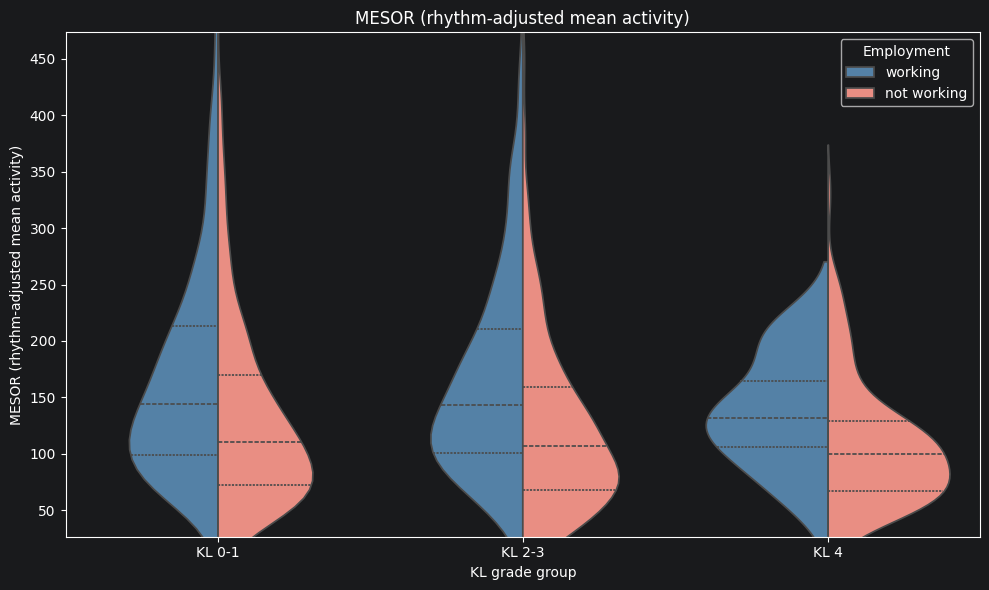

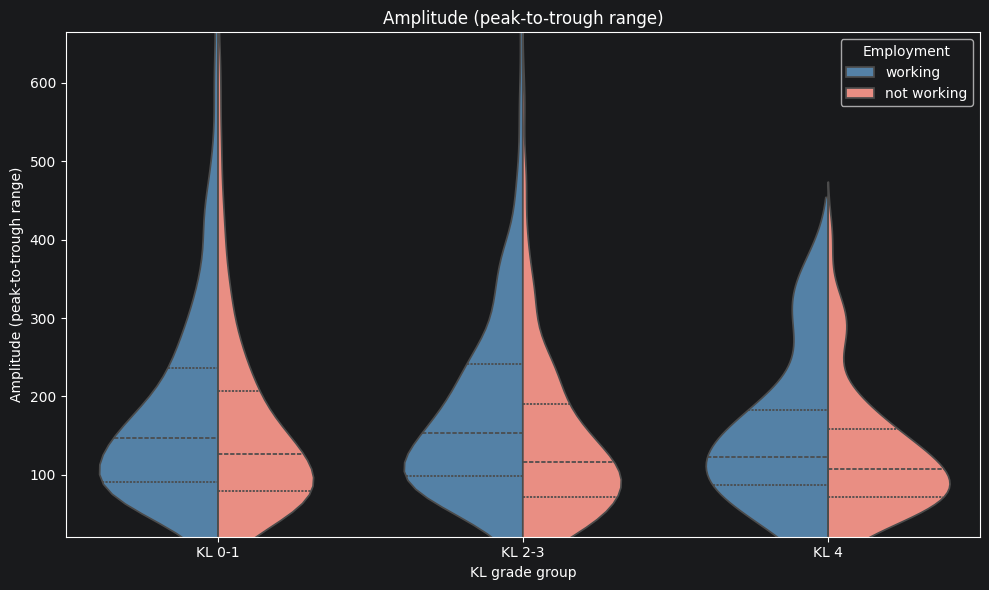

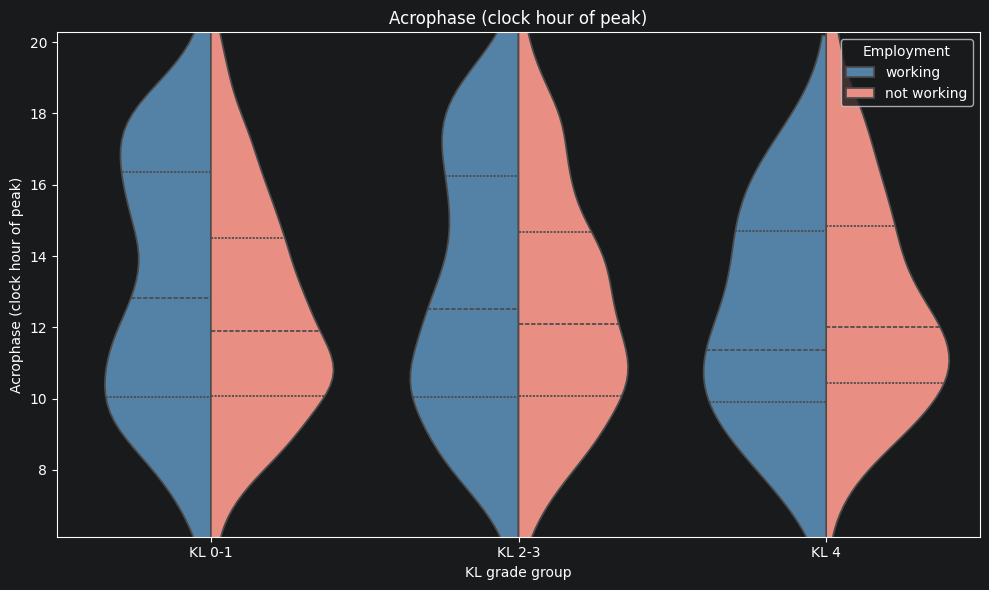

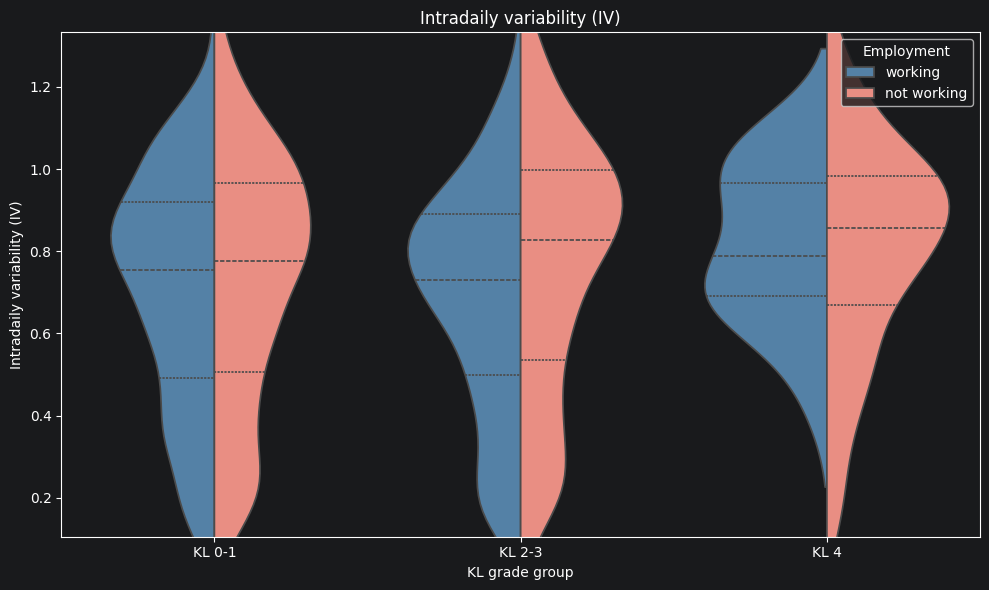

In [112]:
for feature in features_of_interest_daily:
    fig, ax = plt.subplots(figsize=(10, 6))

    sns.violinplot(
        data=daily_metrics_08.dropna(subset=[feature]),
        x="kl_grade_group",
        y=feature,
        hue="employment_group",
        order=kl_order,
        hue_order=["working", "not working"],
        split=True,
        inner="quartile",
        palette={"working": "steelblue", "not working": "salmon"},
        ax=ax,
    )
    ax.set_xlabel("KL grade group")
    ax.set_ylabel(feature_labels[feature])
    ax.set_title(feature_labels[feature])
    ax.set_ylim(y_limits[feature])
    ax.legend(title="Employment", loc="upper right")

    plt.tight_layout()
    plt.show()

## 9.2 Interaction plots

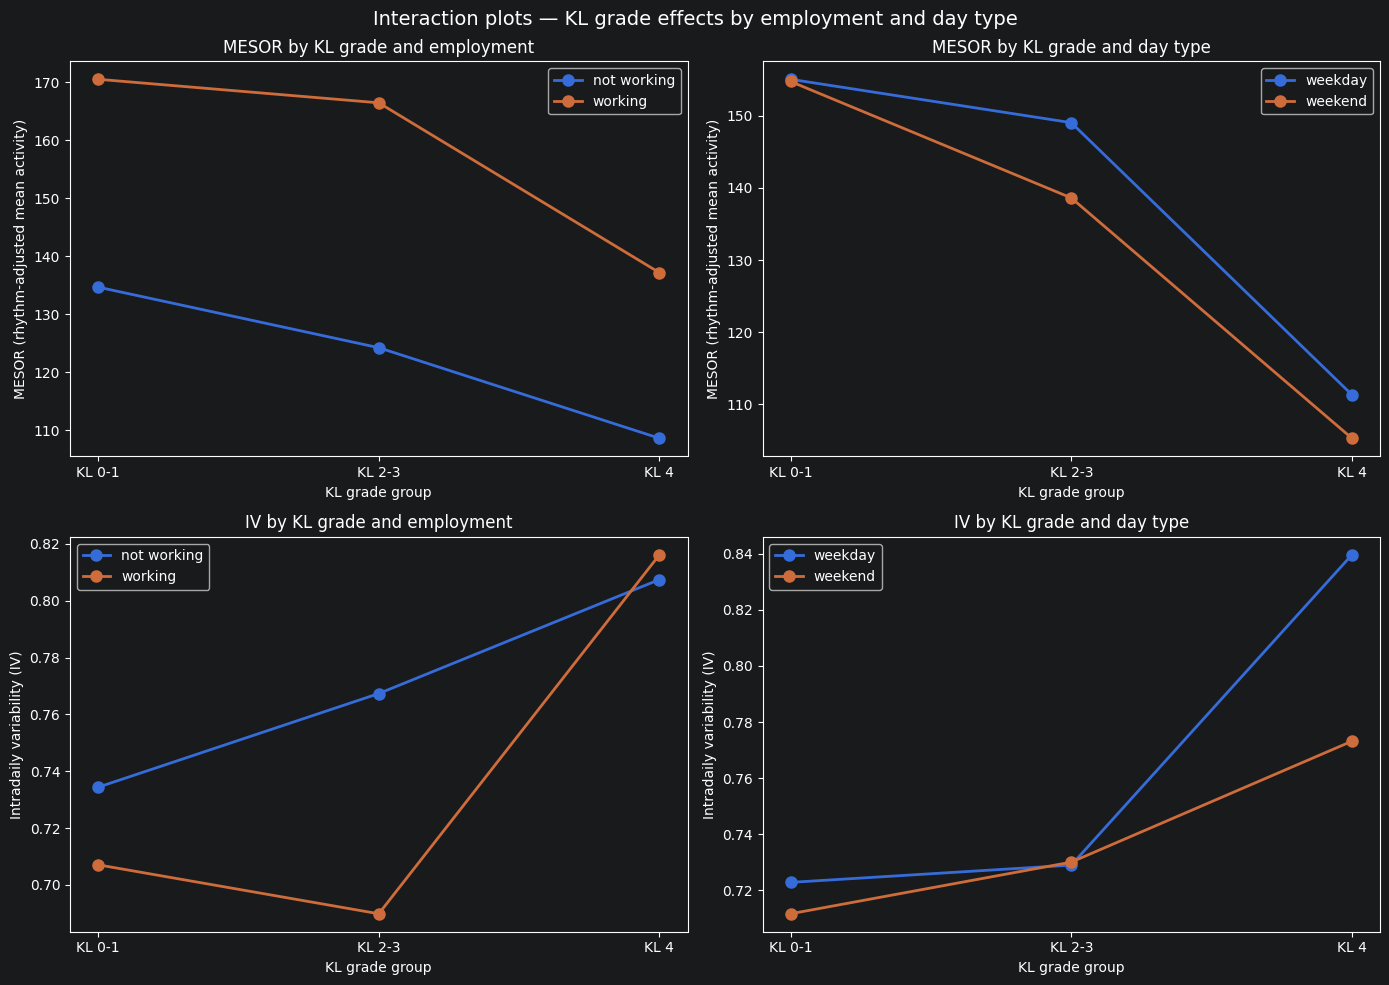

In [113]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))

plot_specifications = [
    {"feature": "mesor_daily", "group": "employment_group", "title": "MESOR by KL grade and employment"},
    {"feature": "mesor_daily", "group": "day_type", "title": "MESOR by KL grade and day type"},
    {"feature": "intradaily_variability_daily", "group": "employment_group", "title": "IV by KL grade and employment"},
    {"feature": "intradaily_variability_daily", "group": "day_type", "title": "IV by KL grade and day type"},
]

for axis, specification in zip(axes.flatten(), plot_specifications):
    plot_data = (
        daily_metrics_08
        .groupby(["kl_grade_group", specification["group"]])[specification["feature"]]
        .mean()
        .reset_index()
    )

    for group_value, group_data in plot_data.groupby(specification["group"]):
        group_data = group_data.sort_values("kl_grade_group")
        axis.plot(
            group_data["kl_grade_group"],
            group_data[specification["feature"]],
            marker="o",
            linewidth=2,
            markersize=8,
            label=group_value,
        )

    axis.set_xlabel("KL grade group")
    axis.set_ylabel(feature_labels[specification["feature"]])
    axis.set_title(specification["title"])
    axis.legend()

plt.suptitle("Interaction plots — KL grade effects by employment and day type", fontsize=14)
plt.tight_layout()
plt.show()

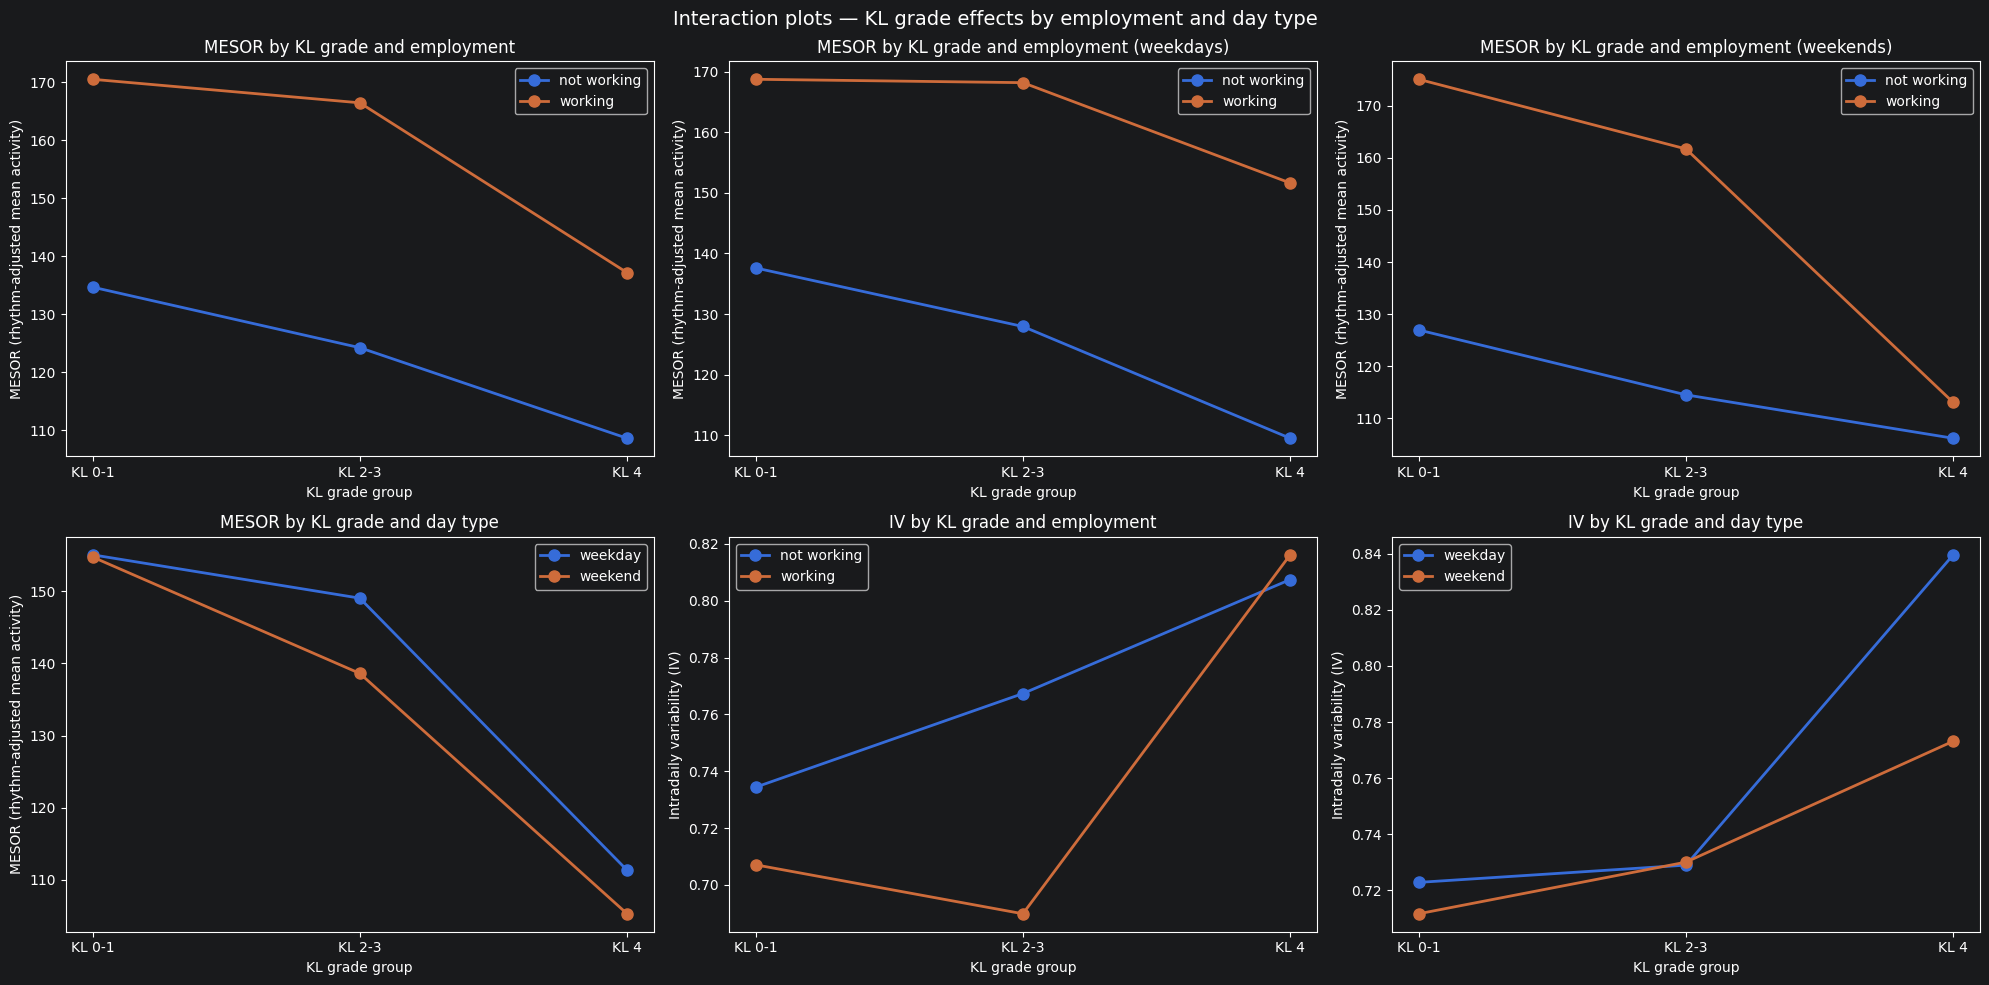

In [114]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(20, 10))

plot_specifications = [
    {
        "feature": "mesor_daily",
        "group": "employment_group",
        "title": "MESOR by KL grade and employment",
        "filter": None,
    },
    {
        "feature": "mesor_daily",
        "group": "employment_group",
        "title": "MESOR by KL grade and employment (weekdays)",
        "filter": {"column": "day_type", "value": "weekday"},
    },
    {
        "feature": "mesor_daily",
        "group": "employment_group",
        "title": "MESOR by KL grade and employment (weekends)",
        "filter": {"column": "day_type", "value": "weekend"},
    },
    {
        "feature": "mesor_daily",
        "group": "day_type",
        "title": "MESOR by KL grade and day type",
        "filter": None,
    },
    {
        "feature": "intradaily_variability_daily",
        "group": "employment_group",
        "title": "IV by KL grade and employment",
        "filter": None,
    },
    {
        "feature": "intradaily_variability_daily",
        "group": "day_type",
        "title": "IV by KL grade and day type",
        "filter": None,
    },
]

for axis, specification in zip(axes.flatten(), plot_specifications):
    data_subset = (
        daily_metrics_08[
            daily_metrics_08[specification["filter"]["column"]] == specification["filter"]["value"]
        ]
        if specification["filter"] is not None
        else daily_metrics_08
    )

    plot_data = (
        data_subset
        .groupby(["kl_grade_group", specification["group"]])[specification["feature"]]
        .mean()
        .reset_index()
    )

    for group_value, group_data in plot_data.groupby(specification["group"]):
        group_data = group_data.sort_values("kl_grade_group")
        axis.plot(
            group_data["kl_grade_group"],
            group_data[specification["feature"]],
            marker="o",
            linewidth=2,
            markersize=8,
            label=group_value,
        )

    axis.set_xlabel("KL grade group")
    axis.set_ylabel(feature_labels[specification["feature"]])
    axis.set_title(specification["title"])
    axis.legend()

plt.suptitle("Interaction plots — KL grade effects by employment and day type", fontsize=14)
plt.tight_layout()
plt.show()

In [115]:
kl_4_employed_participants = summary_metrics_08[
    (summary_metrics_08["kl_grade_index_knee"] == 4) &
    (summary_metrics_08["employment_group"] == "working")
][["ID", "employment_group", "kl_grade_index_knee"]]

print(f"Participants with KL grade 4 and working: {len(kl_4_employed_participants)}")
print(kl_4_employed_participants)

Participants with KL grade 4 and working: 3
          ID employment_group  kl_grade_index_knee
210  9282203          working                    4
223  9302260          working                    4
574  9766889          working                    4


## 9.3 KL4 subgroup exploration

In [116]:
print(
    summary_metrics_08
    .groupby("kl_grade_group")["mesor"]
    .agg(["mean", "median", "count"])
    .round(2)
)

                  mean  median  count
kl_grade_group                       
KL 0-1          152.98  139.15    433
KL 2-3          144.40  132.69    293
KL 4            110.07  106.78     20


In [117]:
print(
    summary_metrics_08
    .groupby(["kl_grade_group", "employment_group"])["mesor"]
    .agg(["mean", "median", "count"])
    .round(2)
)

                                   mean  median  count
kl_grade_group employment_group                       
KL 0-1         not working       132.25  112.83    191
               working           169.05  155.18    231
KL 2-3         not working       121.86  107.71    138
               working           165.14  145.25    151
KL 4           not working       107.86  102.93     16
               working           137.63  138.90      3


In [118]:
print(
    summary_metrics_08
    .groupby(["kl_grade_group", "employment_group"])[["mesor", "V08AGE"]]
    .agg(["mean", "median", "count"])
    .round(2)
)

                                  mesor               V08AGE             
                                   mean  median count   mean median count
kl_grade_group employment_group                                          
KL 0-1         not working       132.25  112.83   191  71.67   72.0   191
               working           169.05  155.18   231  60.96   60.0   231
KL 2-3         not working       121.86  107.71   138  71.73   73.0   138
               working           165.14  145.25   151  63.48   62.0   151
KL 4           not working       107.86  102.93    16  74.38   76.0    16
               working           137.63  138.90     3  69.33   70.0     3


In [119]:
kl_4_employed_ids = [9282203, 9332151, 9352020, 9559860, 9693364, 9766889, 9775951, 9833782, 9847829, 9932578]

print(
    summary_metrics_08[summary_metrics_08["ID"].isin(kl_4_employed_ids)]
    .groupby(["ID"])[["mesor", "V08AGE"]]
    .agg(["mean", "median", "count"])
    .round(2)
)

          mesor               V08AGE             
           mean  median count   mean median count
ID                                               
9282203  138.90  138.90     1   78.0   78.0     1
9766889  125.86  125.86     1   60.0   60.0     1


In [120]:
print(
    f"Participants after synchronisation:\n"
    f"  minute_metrics_08 : {minute_metrics_08['ID'].nunique():,}\n"
    f"  daily_metrics_08  : {daily_metrics_08['ID'].nunique():,}\n"
    f"  summary_metrics_08: {len(summary_metrics_08):,}"
)

Participants after synchronisation:
  minute_metrics_08 : 746
  daily_metrics_08  : 746
  summary_metrics_08: 746
